# 01 EDA — 세 배치의 차이와 모델링 근거

기존 DAY1의 5개 질문·통계·도표·해석을 제출 구조에 옮긴 노트북입니다. 원본은 기존 MAT 세 파일이며, 기본 실행은 동봉 DAY1 결과를 읽습니다. `REBUILD=True`로 원본에서 EDA를 다시 생성할 수 있습니다. 모델 학습은 하지 않습니다.

[원본 확보와 파일 목록](../data/README.md) · [파이프라인](../docs/pipeline.md)


In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Markdown, Image, Code
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/pipeline.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.pipeline import load_config, choose_raw_dir
CONFIG = load_config(ROOT / 'config/model.json')
RAW_DIR = choose_raw_dir(ROOT, CONFIG)
print('프로젝트:', ROOT)
print('원본 폴더:', RAW_DIR)


프로젝트: .
원본 폴더: ../archive


In [2]:
from src.eda.runner import run_eda
import json
OUT = ROOT / 'results/eda'
REBUILD = False  # 원본에서 EDA를 다시 계산하려면 True
if REBUILD:
    run_eda(ROOT, RAW_DIR)
stats = pd.read_csv(OUT / 'summary/batch_stats.csv')
features = pd.read_csv(OUT / 'integrated/cell_features_with_qc.csv')
print('셀 기록:', len(features), '수명 정답 있음:', features.cycle_life.notna().sum())
print('기존 DAY1 EDA 자료이며 DAY2 모델 성능이 아닙니다.')


셀 기록: 139 수명 정답 있음: 129
기존 DAY1 EDA 자료이며 DAY2 모델 성능이 아닙니다.


## 분석 범위와 핵심 결론

분석일은 2026-10-01이며, 목적은 초기 관측에서 배터리 수명 예측에 유용한 특징을 탐색하는 것이다. 분석 대상 **Batch 1=2017-05-12, Batch 2=2018-02-20, Batch 3=2018-04-12**만 포함했다. 총 **139개 셀 기록 중 유한 수명 라벨은 129개**다. Batch 2의 8개와 Batch 3의 2개 결측 라벨은 관측 길이로 채우지 않았다.

이번 EDA에서는 **초기 ΔQ(V)의 로그 분산과 로그 절대 최솟값이 가장 강하고 배치별로 방향이 일관된 후보**다. 초기 총용량·온도·충전시간의 전체 상관은 배치 구성의 영향을 크게 받는다. 전체 곡선은 후기 가속을 보이지만, 사후 Knee와 후기 기울기는 초기 예측에 넣을 수 없다. 모델 학습이나 최종 변수 채택은 수행하지 않았다.

수명 통계는 셀당 한 번씩 계산했다. 사이클 행으로 집계하면 오래 관측한 셀의 가중치가 커진다. `cycle_life`는 제공 라벨이며, 기록된 EOL 통과와 구분했다. 파일 내 식별자는 `B1c20`처럼 배치와 0부터 시작하는 셀 번호를 결합했다. MATLAB 객체형 barcode는 미해독 상태이므로 물리적 셀 동일성을 확정하거나 배치 사이 기록을 이어붙이지 않았다.

**모델링 전 수명 목표값 검토가 필요하다.** B1 유한 라벨 46개와 B3 유한 라벨 44개는 마지막 관측 cycle+1이며, 기록된 유효 QD에서 엄격한 `<0.88Ah` 통과가 보이지 않는다. B2 유한 39개는 최초 `<0.88Ah` 통과 cycle과 일치한다. B1/B3의 기록 중 다수는 임계값 가까이에서 끝나지만, N+1 라벨만으로 모두 완료된 EOL이나 모두 잘못된 라벨이라고 할 수 없다. 실제 종료 사유·연속 실험·라벨 생성 규칙을 확인한 뒤 예측 목표를 확정해야 한다. 이번 EDA에서는 제공 라벨을 보존하고 임의로 재정의하지 않았다. [라벨과 EOL 검토](../results/eda/domain_review.md)

기존 `30-ESSHealth-scratch.ipynb`의 `extract_deltaq`를 실제 선택 자료로 실행해 확인했다. **B1 46개, B2 39개, B3 44개의 ΔQ 분산·최솟값·평균이 별도 계산과 일치**했다. 그 함수는 수명 결측 셀을 제외하며, 보완 EDA의 곡선 그림은 이 10개 셀도 회색으로 표시한다. 수명 상관의 분모는 두 구현 모두 129개다. [검증 결과](../results/eda/verification.json)

| 배치 | 셀 기록 | 유효 라벨 | 평균 | 중앙값 | 표준편차 | 최소 | 최대 |
| --- | --- | --- | --- | --- | --- | --- | --- |
| B1 | 46 | 46 | 844.7 | 858.5 | 184.6 | 534.0 | 1227.0 |
| B2 | 47 | 39 | 565.7 | 472.0 | 222.2 | 392.0 | 1186.0 |
| B3 | 46 | 44 | 1059.7 | 1005.5 | 313.9 | 541.0 | 1935.0 |

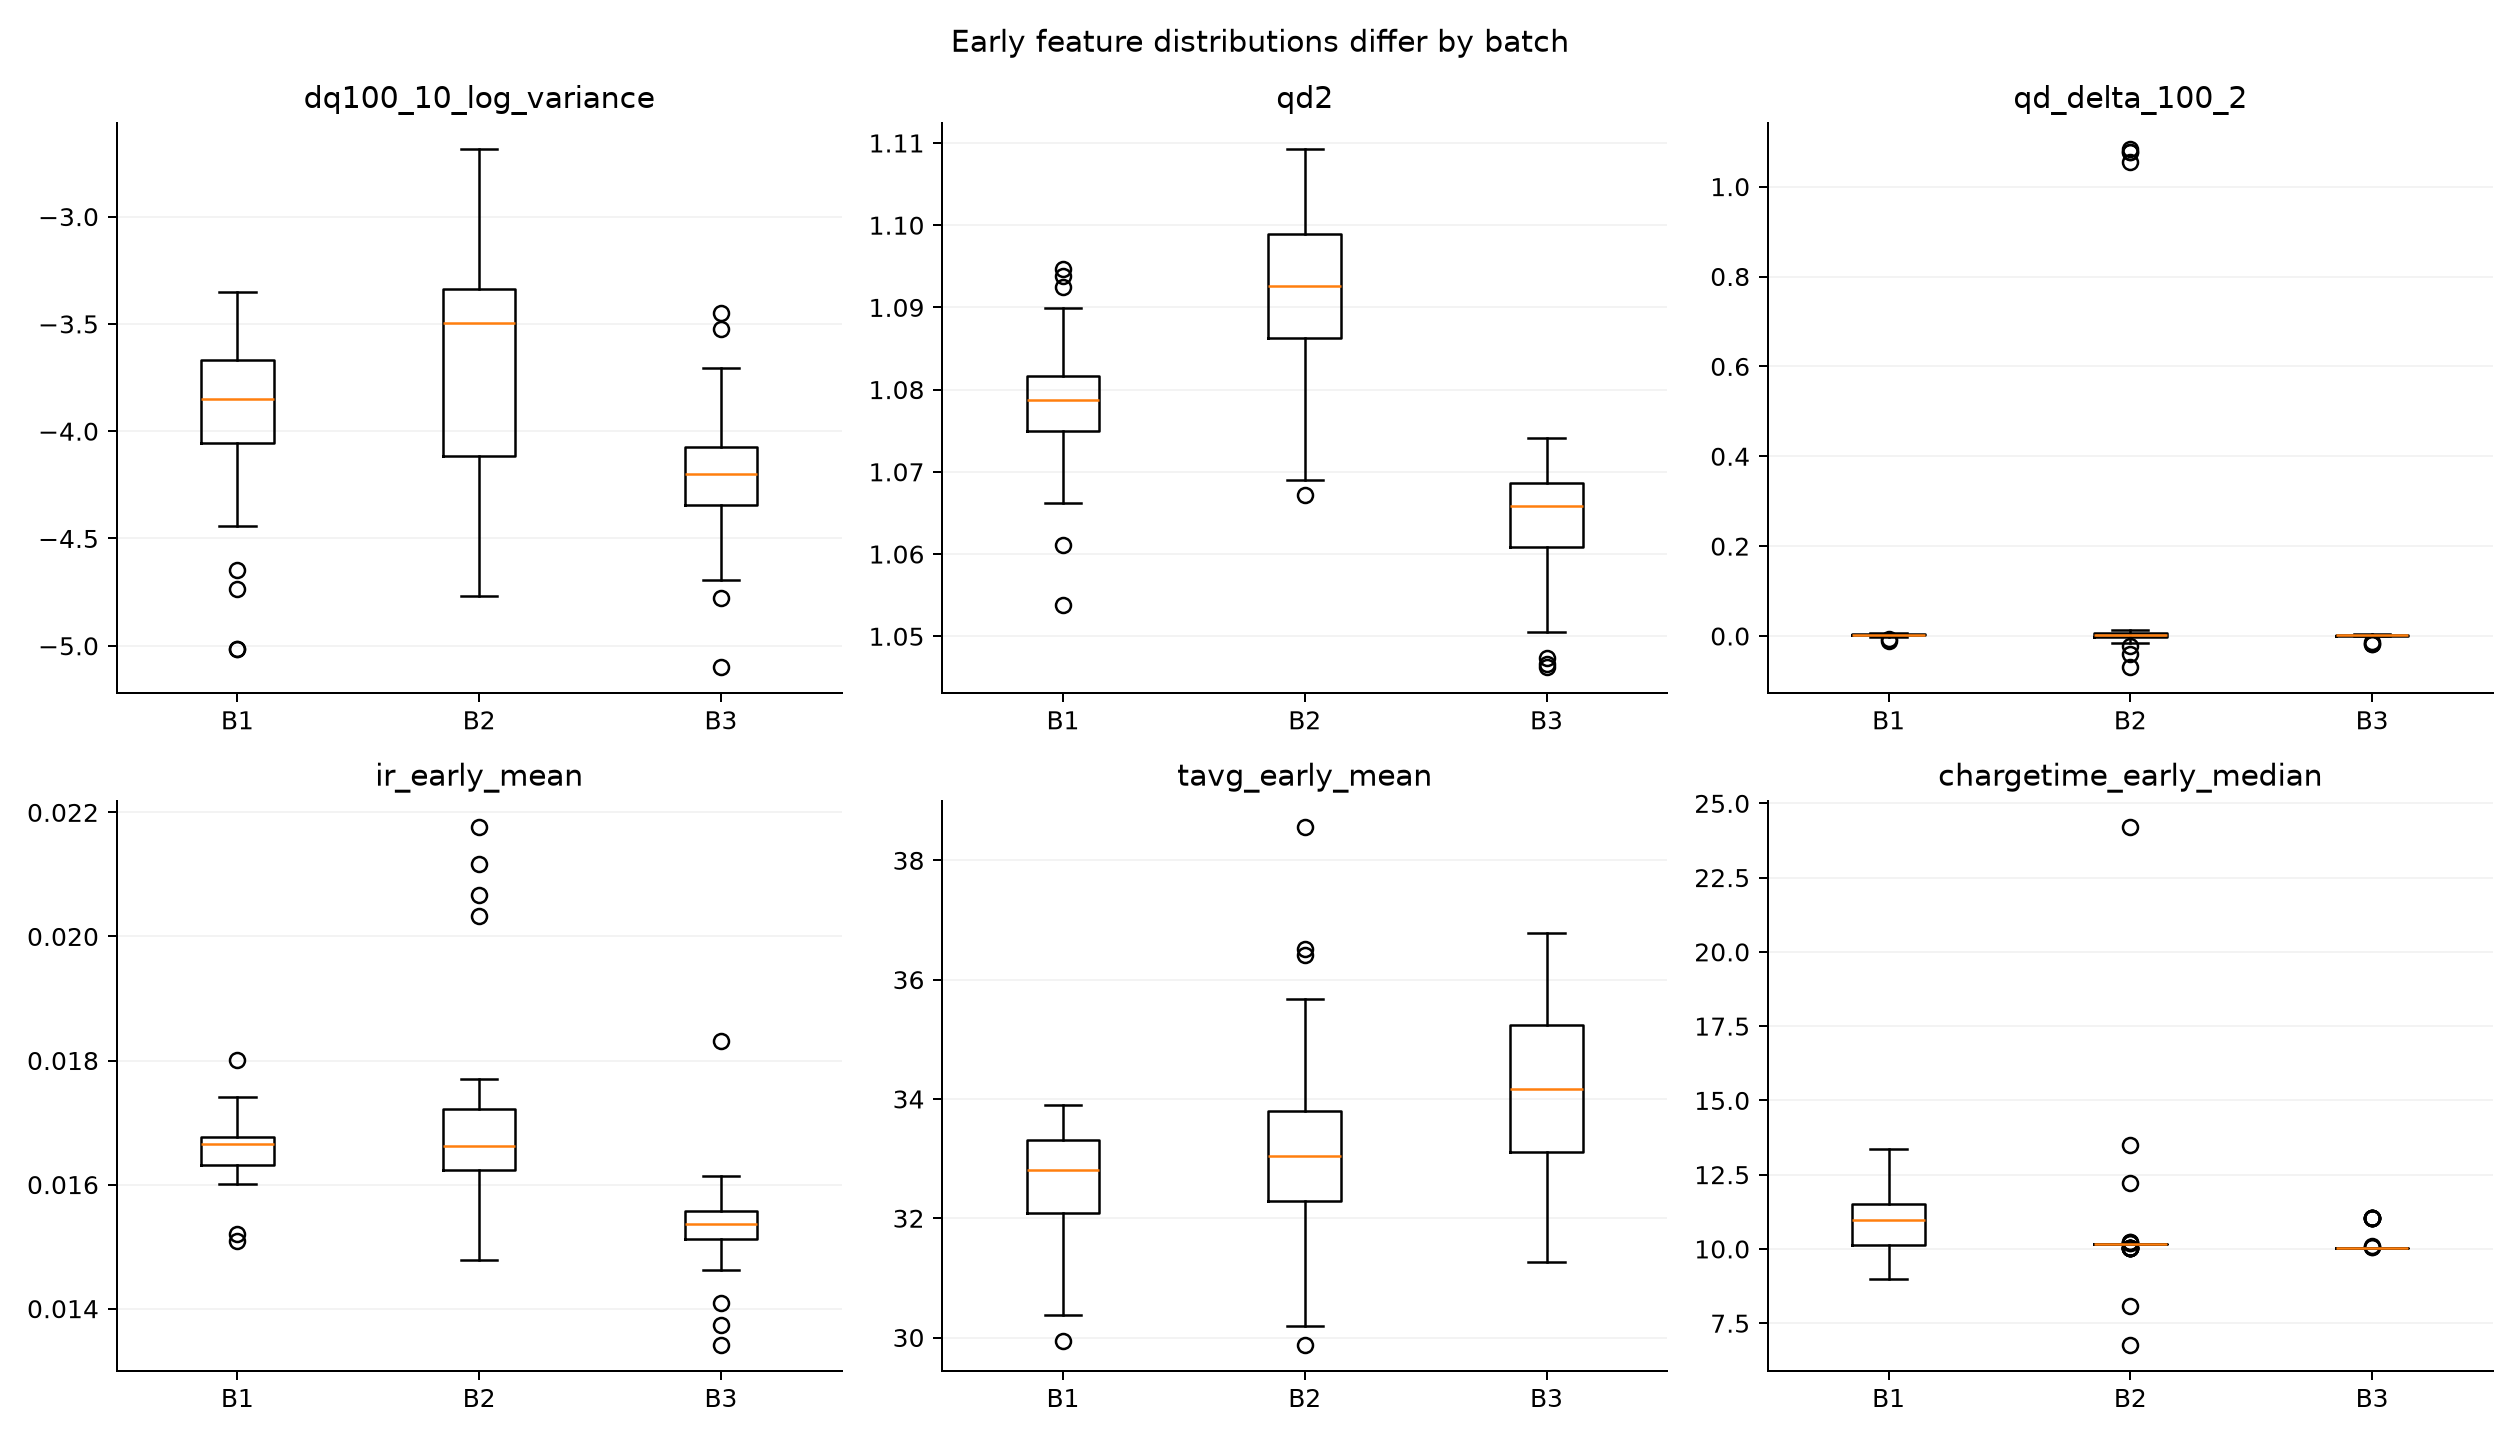

In [3]:
display(Image(filename=str(OUT / 'integrated/core_feature_distributions.png')))


## 1 수명 분포와 짧은 셀의 해석

히스토그램은 요청대로 **150–2300사이클**을 공통 x축으로 사용했다. 선택 자료의 실제 라벨 범위는 **392–1935사이클**이며, 논문의 150–2300 범위가 이 로컬 자료에 그대로 존재하는 것은 아니다.

| 배치 | 단수명 <500 | 장수명 >1000 | 왜도 | IQR 하단 이상치 | IQR 상단 이상치 |
| --- | --- | --- | --- | --- | --- |
| B1 | 0/46 (0.0%) | 10/46 (21.7%) | 0.453 | 0 | 0 |
| B2 | 28/39 (71.8%) | 3/39 (7.7%) | 1.637 | 0 | 9 |
| B3 | 0/44 (0.0%) | 23/44 (52.3%) | 1.255 | 0 | 3 |

Batch 1은 700–900사이클 부근에 상대적으로 집중하고 약한 오른쪽 꼬리를 보인다. Batch 2는 중앙값 472사이클이며 500 미만이 71.8%인 짧은 수명 집단과 일부 긴 수명 꼬리가 공존한다. Batch 3은 중앙값 1005.5사이클이고 1000 초과가 52.3%다. 이 차이 때문에 배치 통합 분포는 하나의 균질한 모집단으로 해석하기 어렵다.

**각 배치에서 1.5×IQR 하단 이상치는 없다.** Batch 2의 단수명 28개는 이 배치의 다수이며 통계적 저수명 이상치가 아니다. 상단 이상치는 B2 9개, B3 3개지만 긴 수명을 데이터 오류로 보고 자동 삭제하지 않았다. B2의 상단 9개는 모두 `-newstructure` 스케줄 이름을 갖는다. 정책 이름을 합치기 전 집단 차이를 확인해야 하는 단서이며 물리적 원인 확인은 아니다.

짧은 대표 셀은 B1c20=534, B2c19=392, B3c28=541사이클이다. B1c20·21의 `5.4C(80%)-5.4C` 평균은 546.5(n=2), 같은 첫 전류에서 60% 이후 낮추는 `5.4C(60%)-3.6C`는 859.5(n=2)다. **고전류를 유지하는 SOC 구간**이 설명 후보인 이유다. 다만 2셀씩의 관찰 비교이며 초기 온도·IR이 특별히 높다는 근거도 없어 원인이나 열화 기전을 확정하지 않았다.

[히스토그램](../results/eda/summary/01_life_histograms.png), [짧은 셀 및 이상치 표](../results/eda/summary/short_and_outlier_cells.csv)

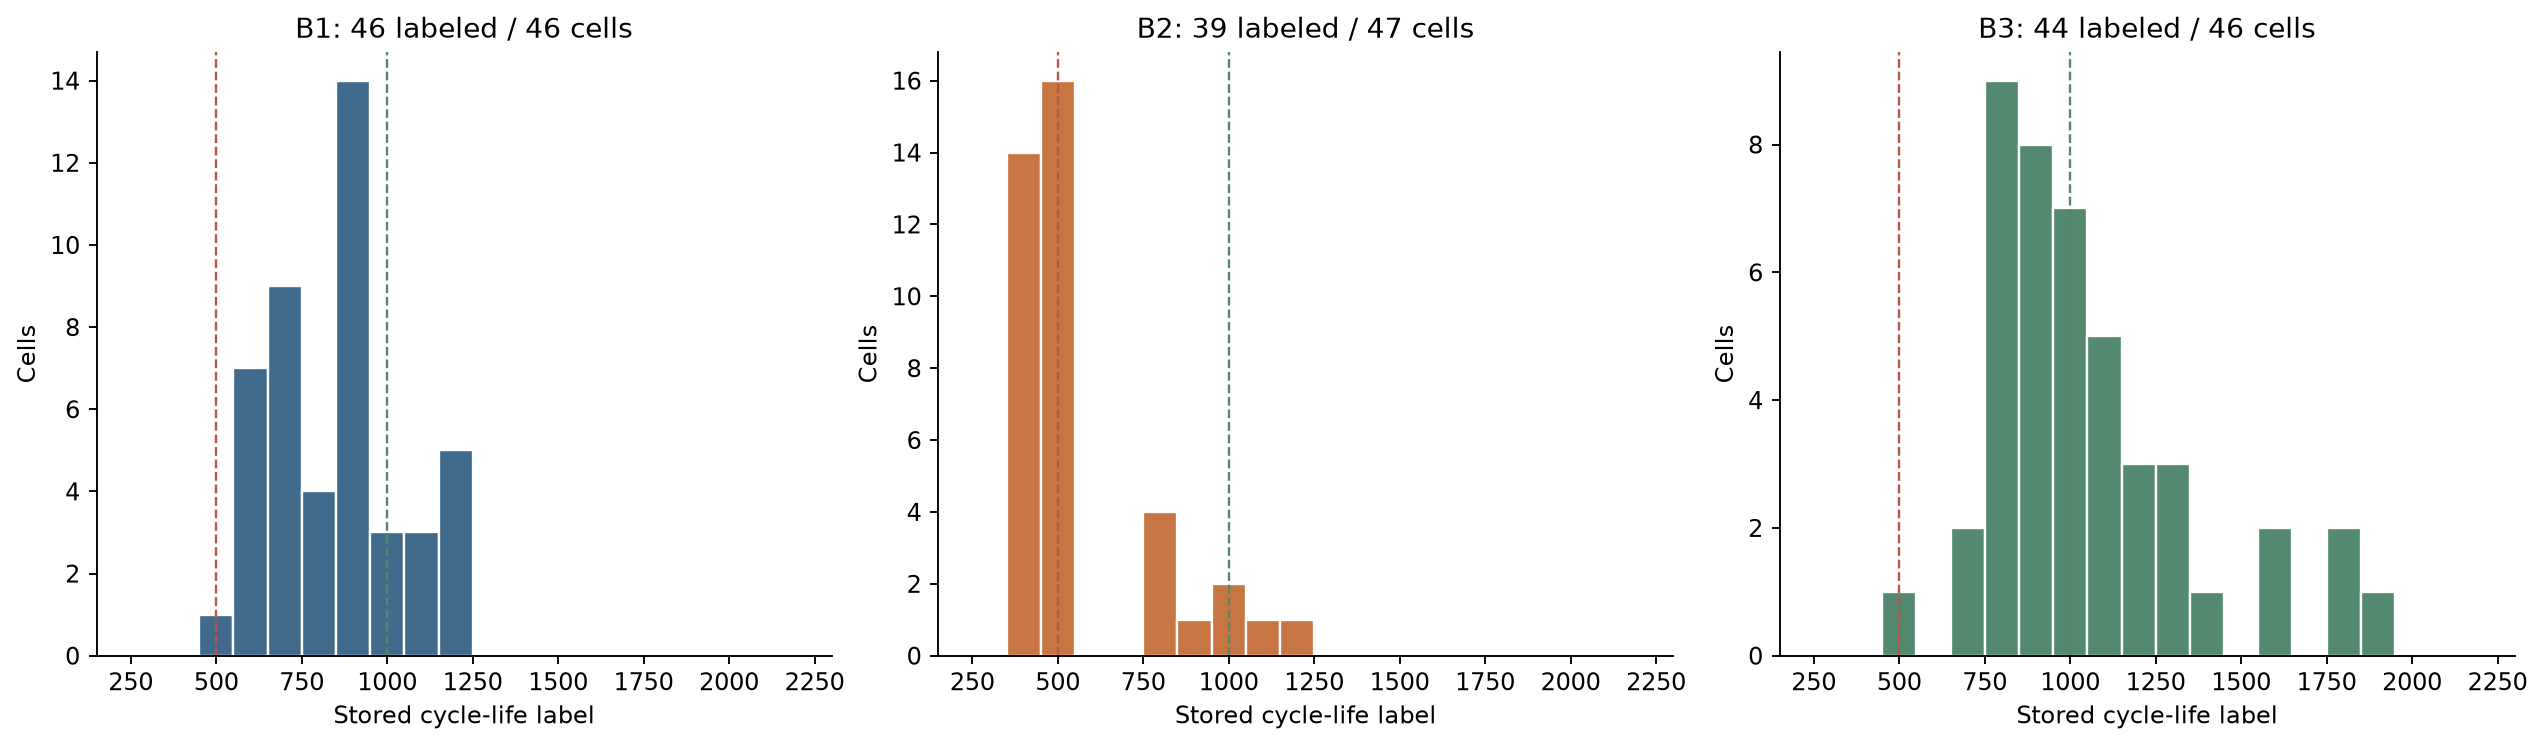

In [4]:
display(Image(filename=str(OUT / 'summary/01_life_histograms.png')))


## 2 방전 용량 감소와 Knee 탐색

전체 QD 곡선과 초기 2–100사이클을 나누어 그렸다. 첫 zero placeholder는 실제 용량으로 해석하지 않았고, EOL 아래 값을 일괄 삭제하지 않았다. 고용량·스파이크는 원시값과 QC 표시를 보존했다. EOL 선은 **정격 1.1Ah×80%=0.88Ah**다. [원 논문 실험 방법](https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf)

초기 용량이 조금 증가하거나 거의 평탄한 셀도 있어 전체 열화를 일정한 직선 감소로 요약하기 어렵다. 특히 B2c19는 QD2=1.09024Ah, QD100=1.09306Ah로 초기 총용량이 증가했지만 수명 라벨은 392다. 초기 QD 감소가 작다는 사실은 긴 수명의 보장이 아니다.

Knee는 cycle 20 이후 median 15 평활 곡선에 연속 2구간 직선을 적합해 탐색했다. 단일 직선보다 SSE가 20% 이상 줄고, 후기 기울기가 더 음수이며 최소 전후 관측 길이를 만족할 때 후보로 표시했다. 이는 회고적 곡률 요약이며 물리적 change point 확정이 아니다. 1.65Ah 초과 경험 9개 셀을 별도 집계한 130개 셀의 결과는 다음과 같다.

| 배치 | QC 비교 셀 | Knee 후보 | Knee 중앙값 | 관측 span 위치 % | 후기20% 감소속도 mAh/cycle |
| --- | --- | --- | --- | --- | --- |
| B1 | 45 | 44 | 619.5 | 74.5 | 0.8 |
| B2 | 39 | 39 | 365.0 | 73.9 | 1.9 |
| B3 | 46 | 46 | 832.0 | 79.3 | 0.7 |

Batch 2의 후보가 절대 사이클 기준 더 이르고 후기 감소속도도 크다. 관측 span 내 위치는 대략 74–79%에 집중한다. 다만 이 비율은 **관측 구간에 대한 위치**이며 실제 수명 대비 비율이 아니다. 7/15 평활 창의 최대 후보 이동은 B1/B2/B3에서 2/2/1사이클이다. B2는 최초 EOL 통과까지만 사용하면 이동 중앙값 18, 최대 55사이클이며 39개 중 29개만 관측 span 5% 내에서 안정적이다. 관측 종료 조건에 따른 민감도를 함께 보고해야 한다.

B1c20의 후보는 418사이클, 전후 감소속도는 0.276→0.716mAh/cycle다. B2c19는 308사이클, 0.143→2.108mAh/cycle다. B3c28은 379사이클, 0.238→0.489mAh/cycle다. B1c0는 단일 직선 대비 개선이 13.9%여서 후보 기준을 충족하지 않았지만 이를 일정한 열화가 확정된 것으로 해석하지 않았다.

Knee·후기 속도·최종 용량·전체 관측 길이는 **곡선 설명 또는 QC용**이며 초기 100사이클 예측 입력에서 제외한다. [전체 및 초기 곡선](../results/eda/summary/03_qd_full_and_early.png), [Knee 대표 그래프](../results/eda/knee/knee_representative_fits.png), [탐지 기준과 민감도](../results/eda/knee/findings.md)

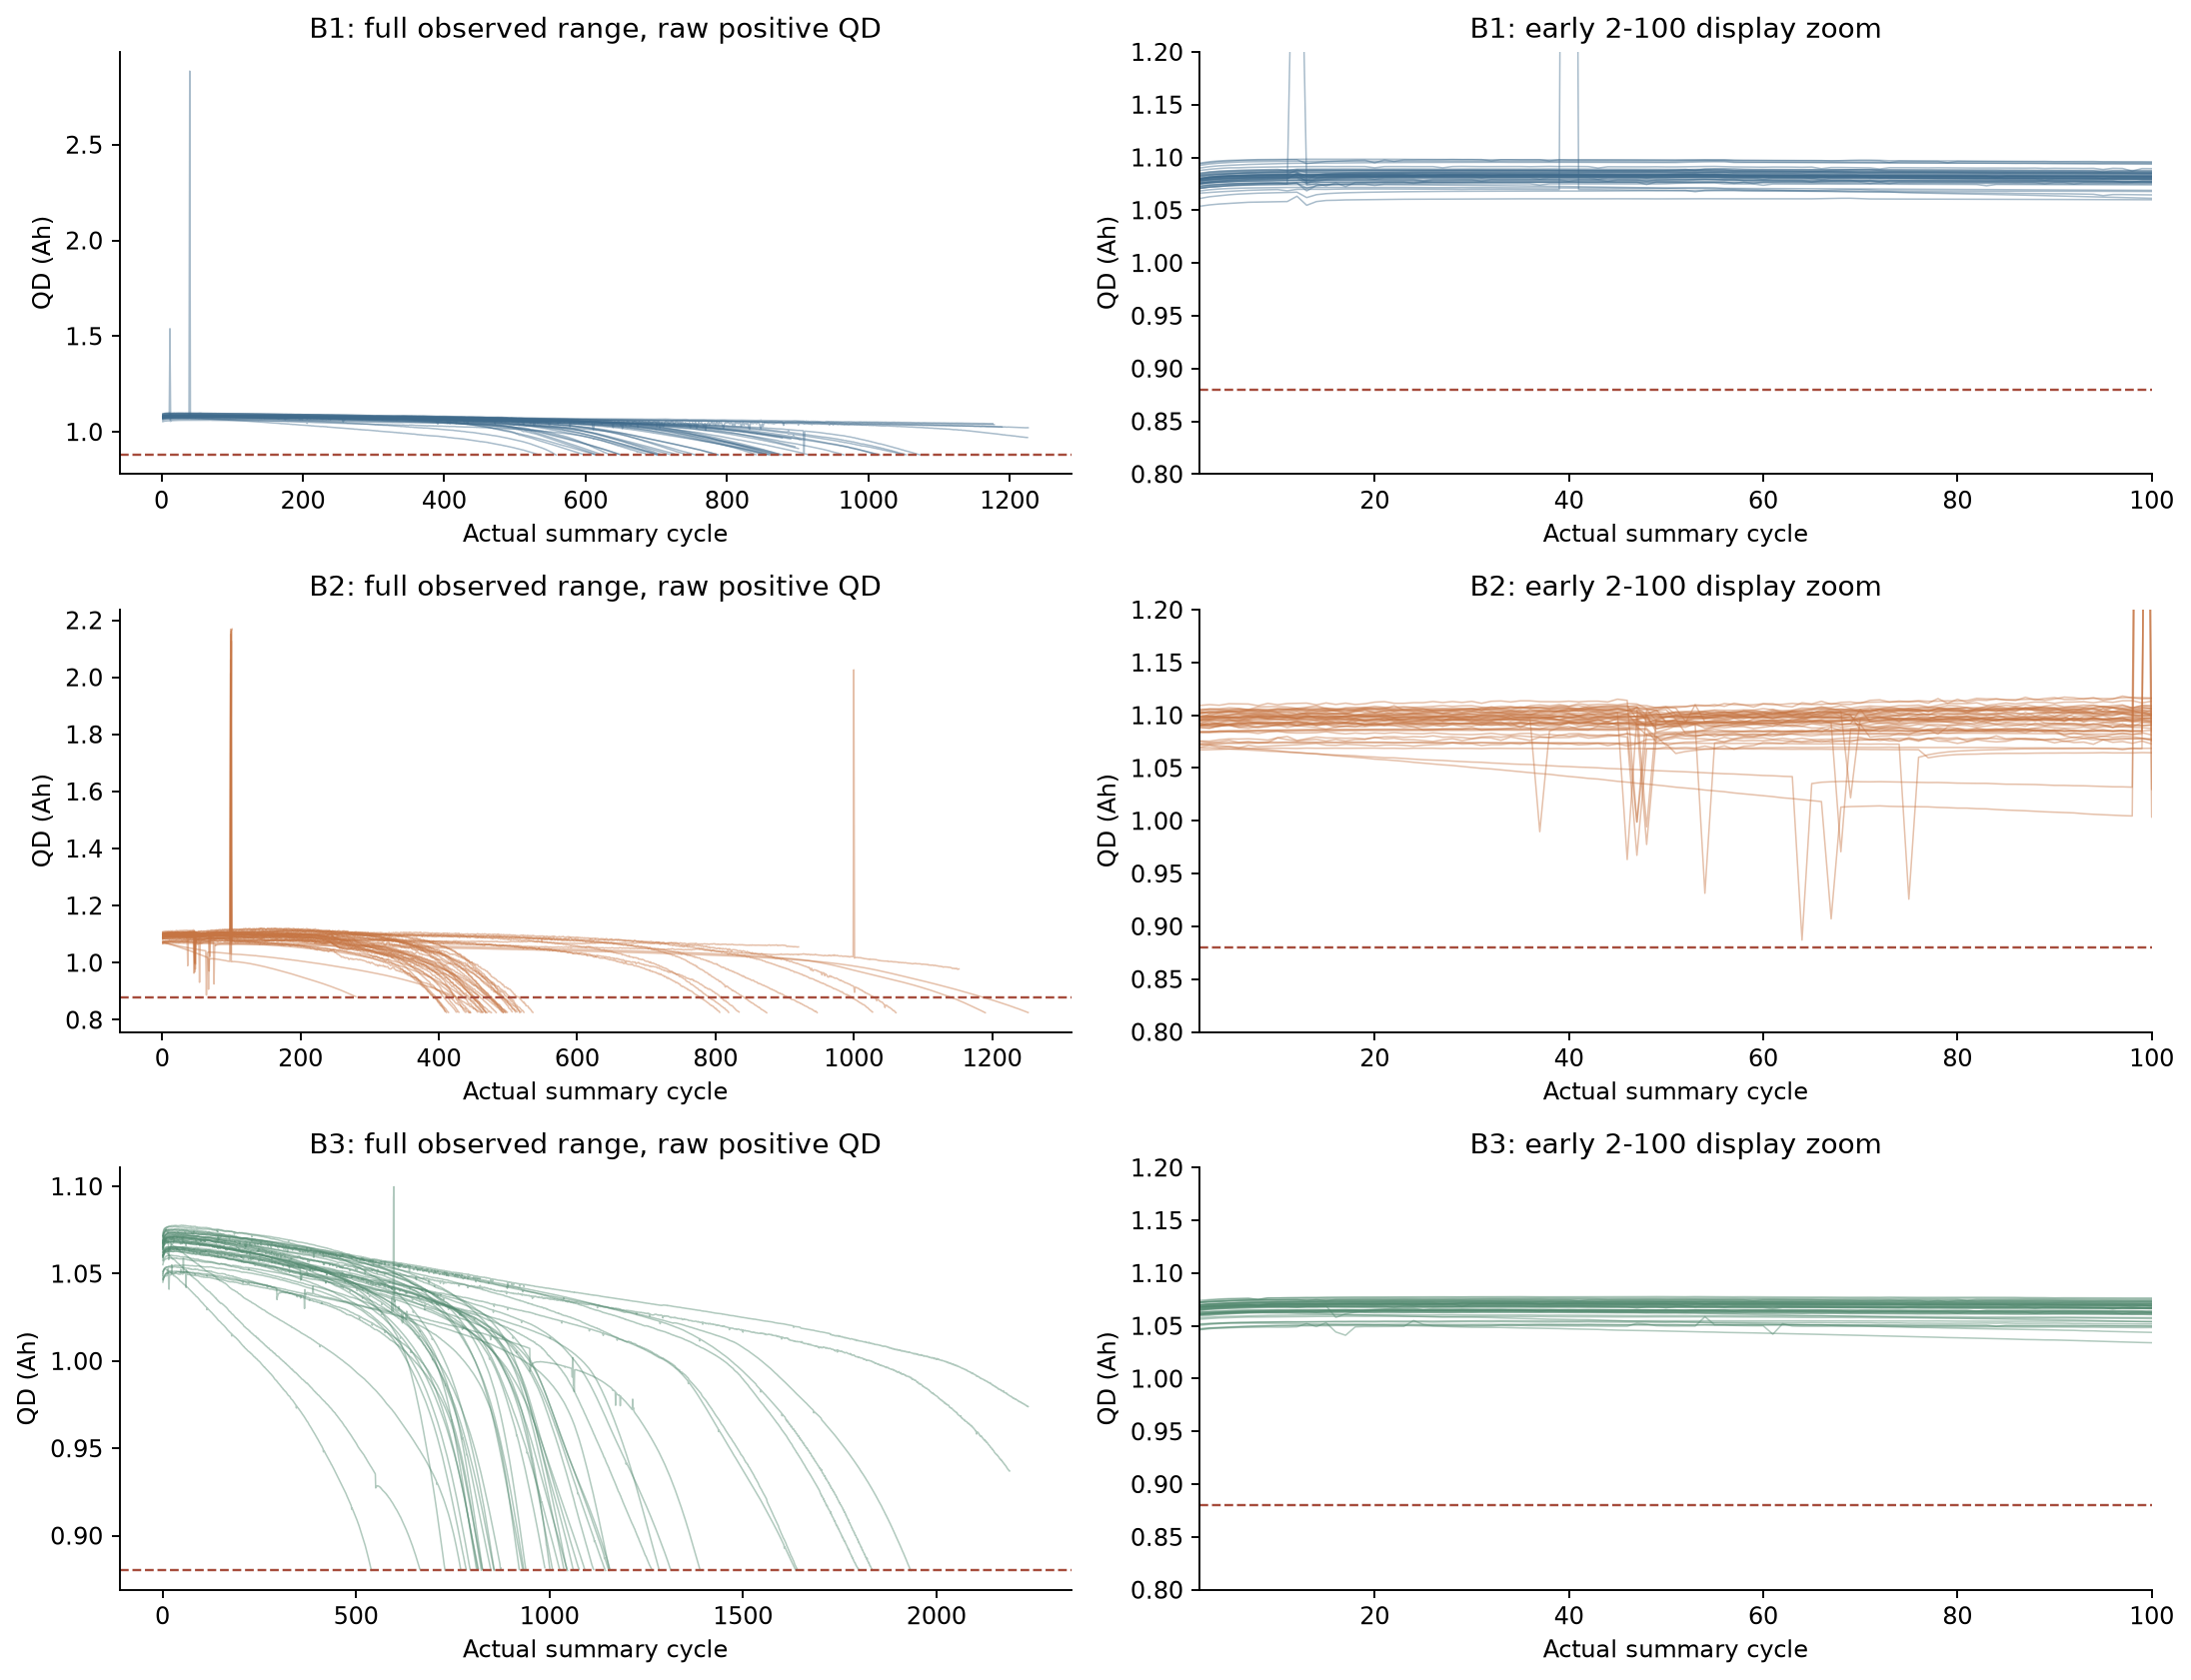

In [5]:
display(Image(filename=str(OUT / 'summary/03_qd_full_and_early.png')))


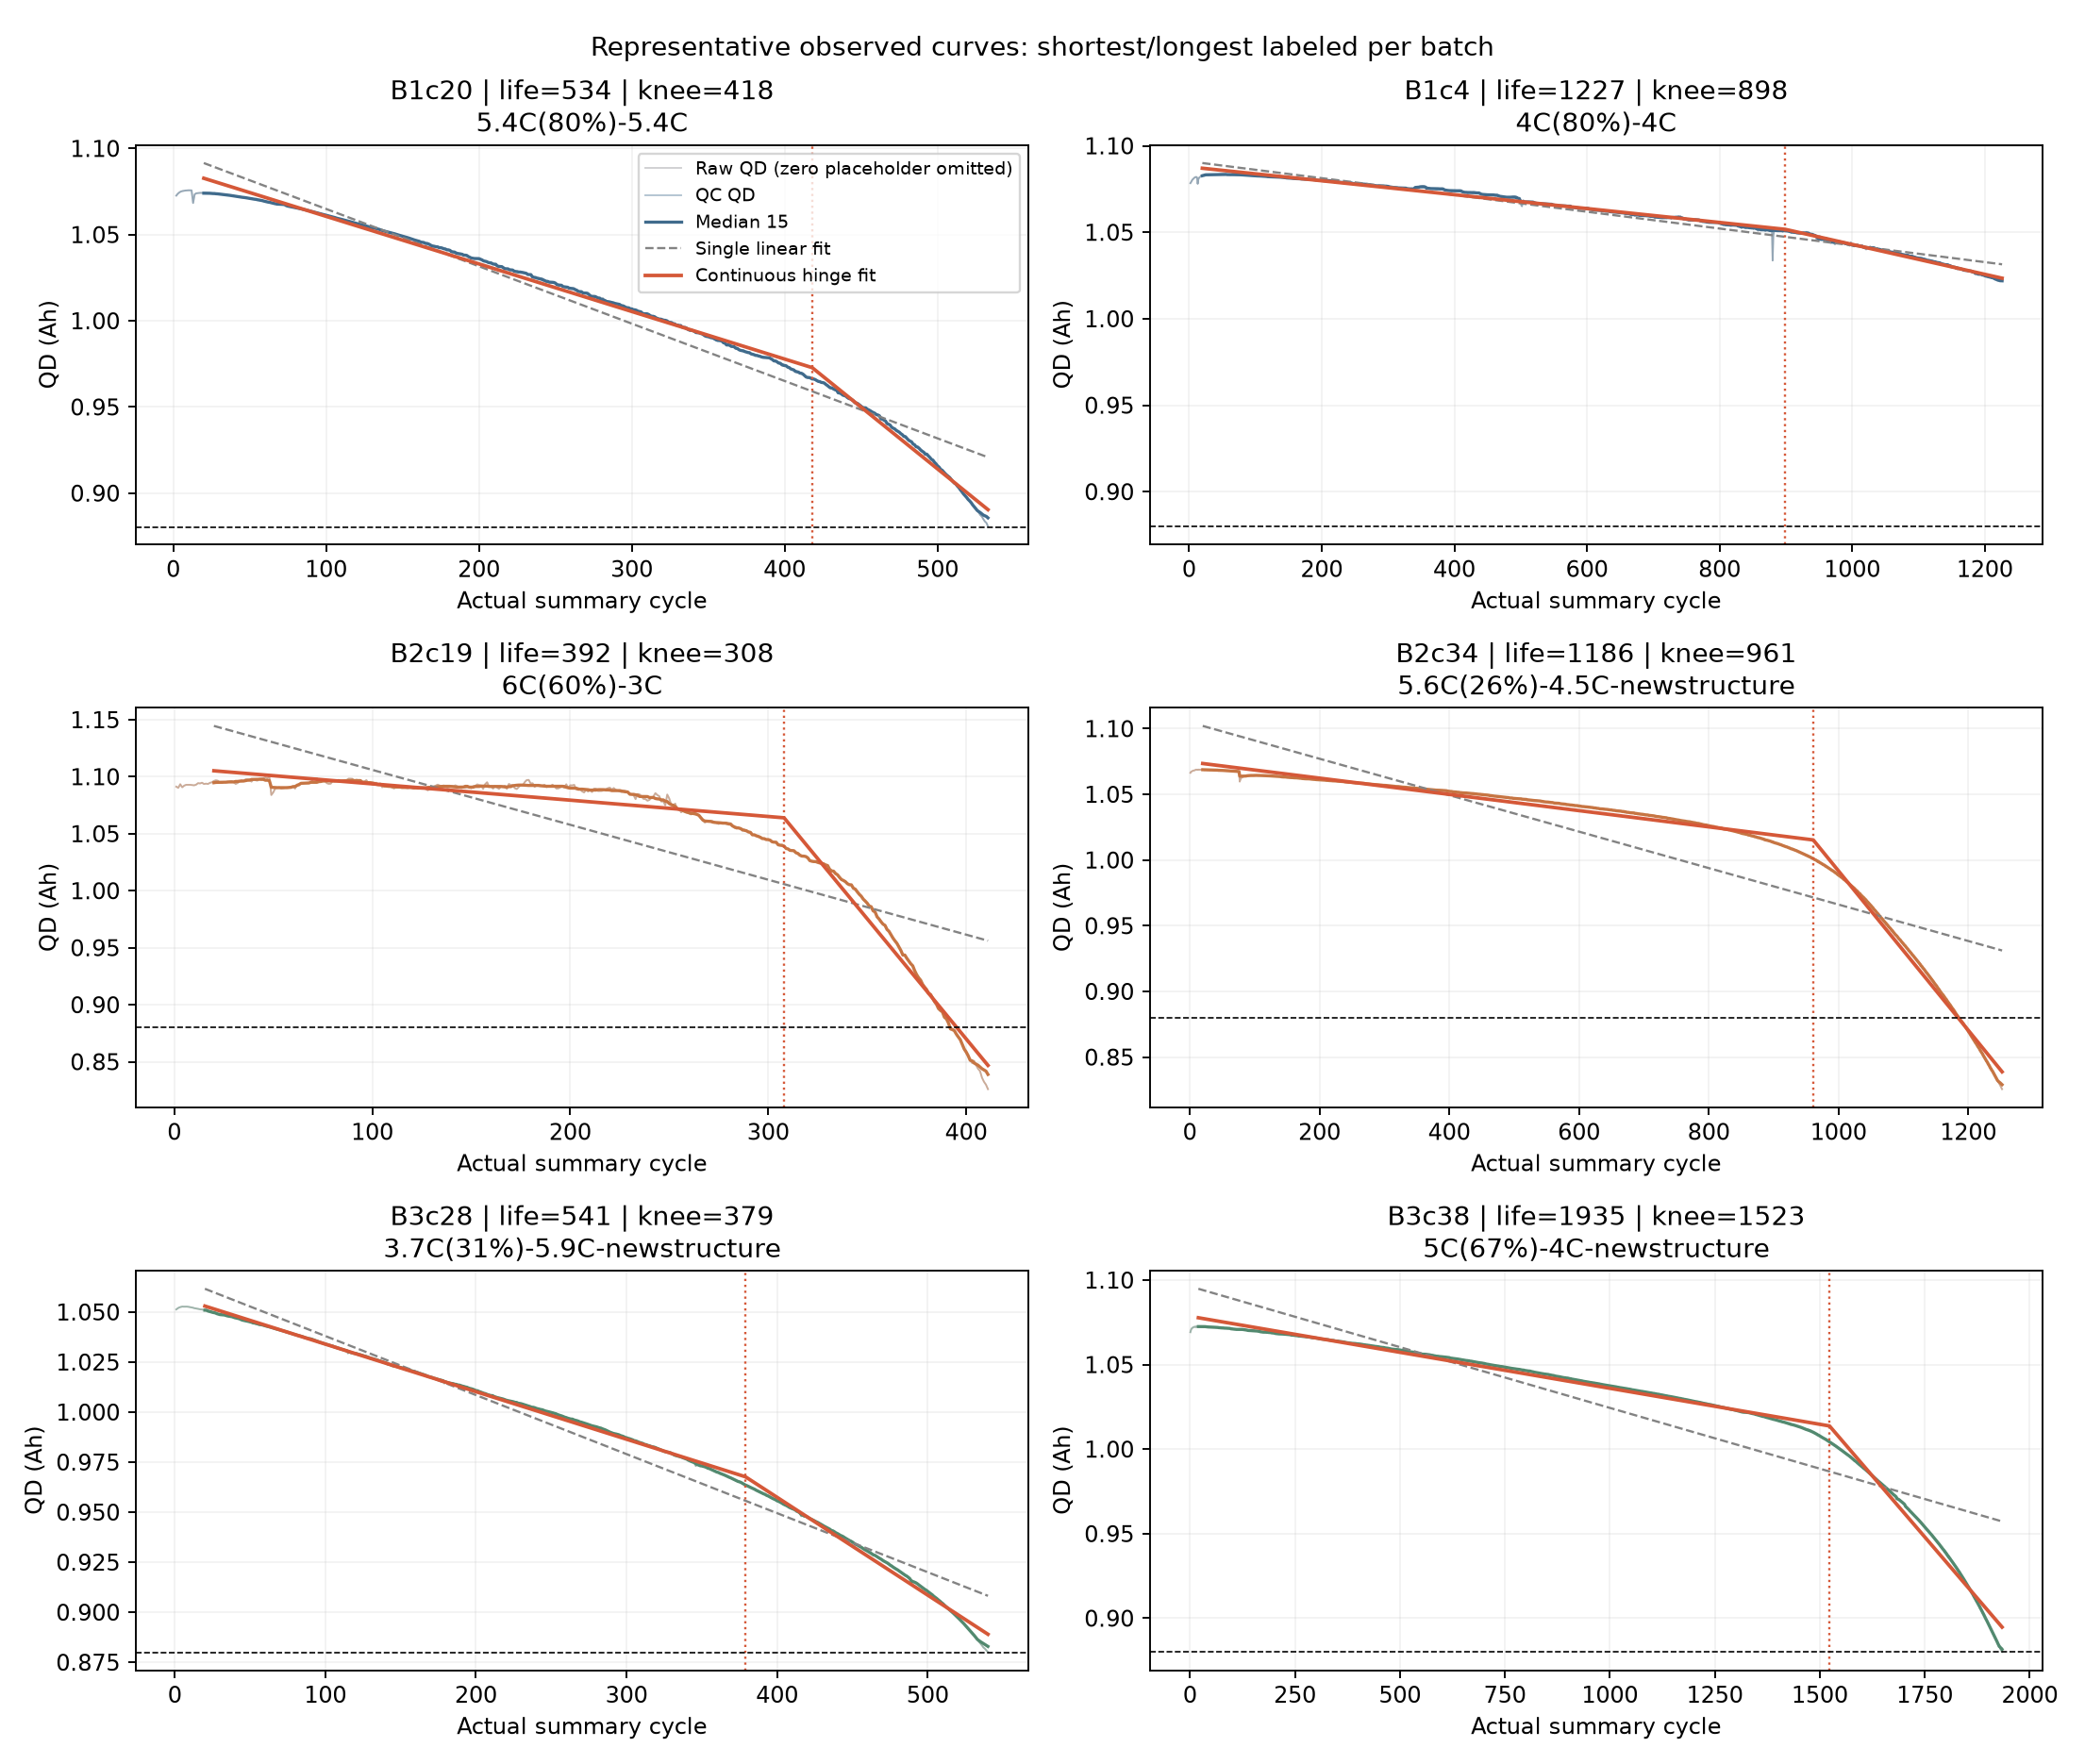

In [6]:
display(Image(filename=str(OUT / 'knee/knee_representative_fits.png')))


## 3 초기 ΔQ(V) 형태와 통계 특징

사이클 차분 방향을 고정해 **ΔQ(V)=Q100(V)−Q10(V)**를 계산했다. 실제 summary 사이클 10·100과 위치 9·99의 대응을 확인했으며, 139개 셀 모두 동일한 **3.5→2.0V, 1000점 Vdlin**을 사용한다. 원시 가변 길이 `cycles.V`를 보간 곡선의 전압축으로 붙이지 않았다.

0 아래 값은 같은 전압에서 Q100이 Q10보다 작다는 뜻이다. 단수명 곡선은 대체로 더 깊은 음의 변화와 큰 형태 변화를 보이고, 장수명은 변화 폭이 작다. 전압 곡선 차이는 총용량 하나보다 많은 정보를 담지만 특정 전기화학 기전을 직접 확인한 값은 아니다.

| life_group | n | log_variance_median | delta_min_median | delta_mean_median |
| --- | --- | --- | --- | --- |
| short_lt500 | 28 | -3.446 | -0.056 | -0.029 |
| middle_500_1000 | 65 | -3.952 | -0.032 | -0.015 |
| long_gt1000 | 36 | -4.311 | -0.020 | -0.009 |

단수명 28개는 모두 B2에 있으므로 전체 장단수명 비교에는 배치 차이가 섞인다. 이를 보완해 배치별 하위·상위 수명 사분위 곡선도 비교했다. 이 사분위 집단을 `<500`, `>1000`이라는 고정 EDA 구간과 혼동하지 않았다.

추출한 핵심 특징은 `log10(var(ΔQ, ddof=1))`와 `log10(abs(min(ΔQ)))`다. 로그는 크기의 범위를 압축하며, 음의 최솟값에 바로 로그를 취하지 않는다. 로그 분산–수명 Pearson은 전체 **−0.851**, B1 **−0.886**, B2 **−0.902**, B3 **−0.702**이며 전체 Spearman은 **−0.892**다. 배치별 평균 차이를 제거해도 Pearson **−0.773**으로 음의 관계가 유지된다.

끝 QD≤0.89Ah의 119개 민감도 집합에서도 r=−0.857이다. 이 조건은 종료점 QC 근사이며 실제 EOL 도달이나 검열 상태의 증명이 아니다. 저자 코드가 수집 문제를 언급한 원래 B3c37을 제외해도 전체 r=−0.848, B3 r=−0.720으로 방향은 유지됐다. [공식 처리 코드](https://github.com/rdbraatz/data-driven-prediction-of-battery-cycle-life-before-capacity-degradation/blob/master/LoadData.m)

관측 시점을 앞당기면 로그 분산–수명 관계는 ΔQ5−2 r=−0.126, ΔQ20−10 r=−0.312로 약해진다. **초기 100사이클에서 얻은 결과를 초기 5사이클 분류의 근거로 그대로 옮길 수 없다.**

[전압별 차이](../results/eda/delta/delta_q_curves.png), [장단수명 형태](../results/eda/delta/delta_life_group_shapes.png), [관측 창 비교](../results/eda/delta/delta_observation_windows.png), [셀별 ΔQ 통계](../results/eda/delta/delta_features.csv)

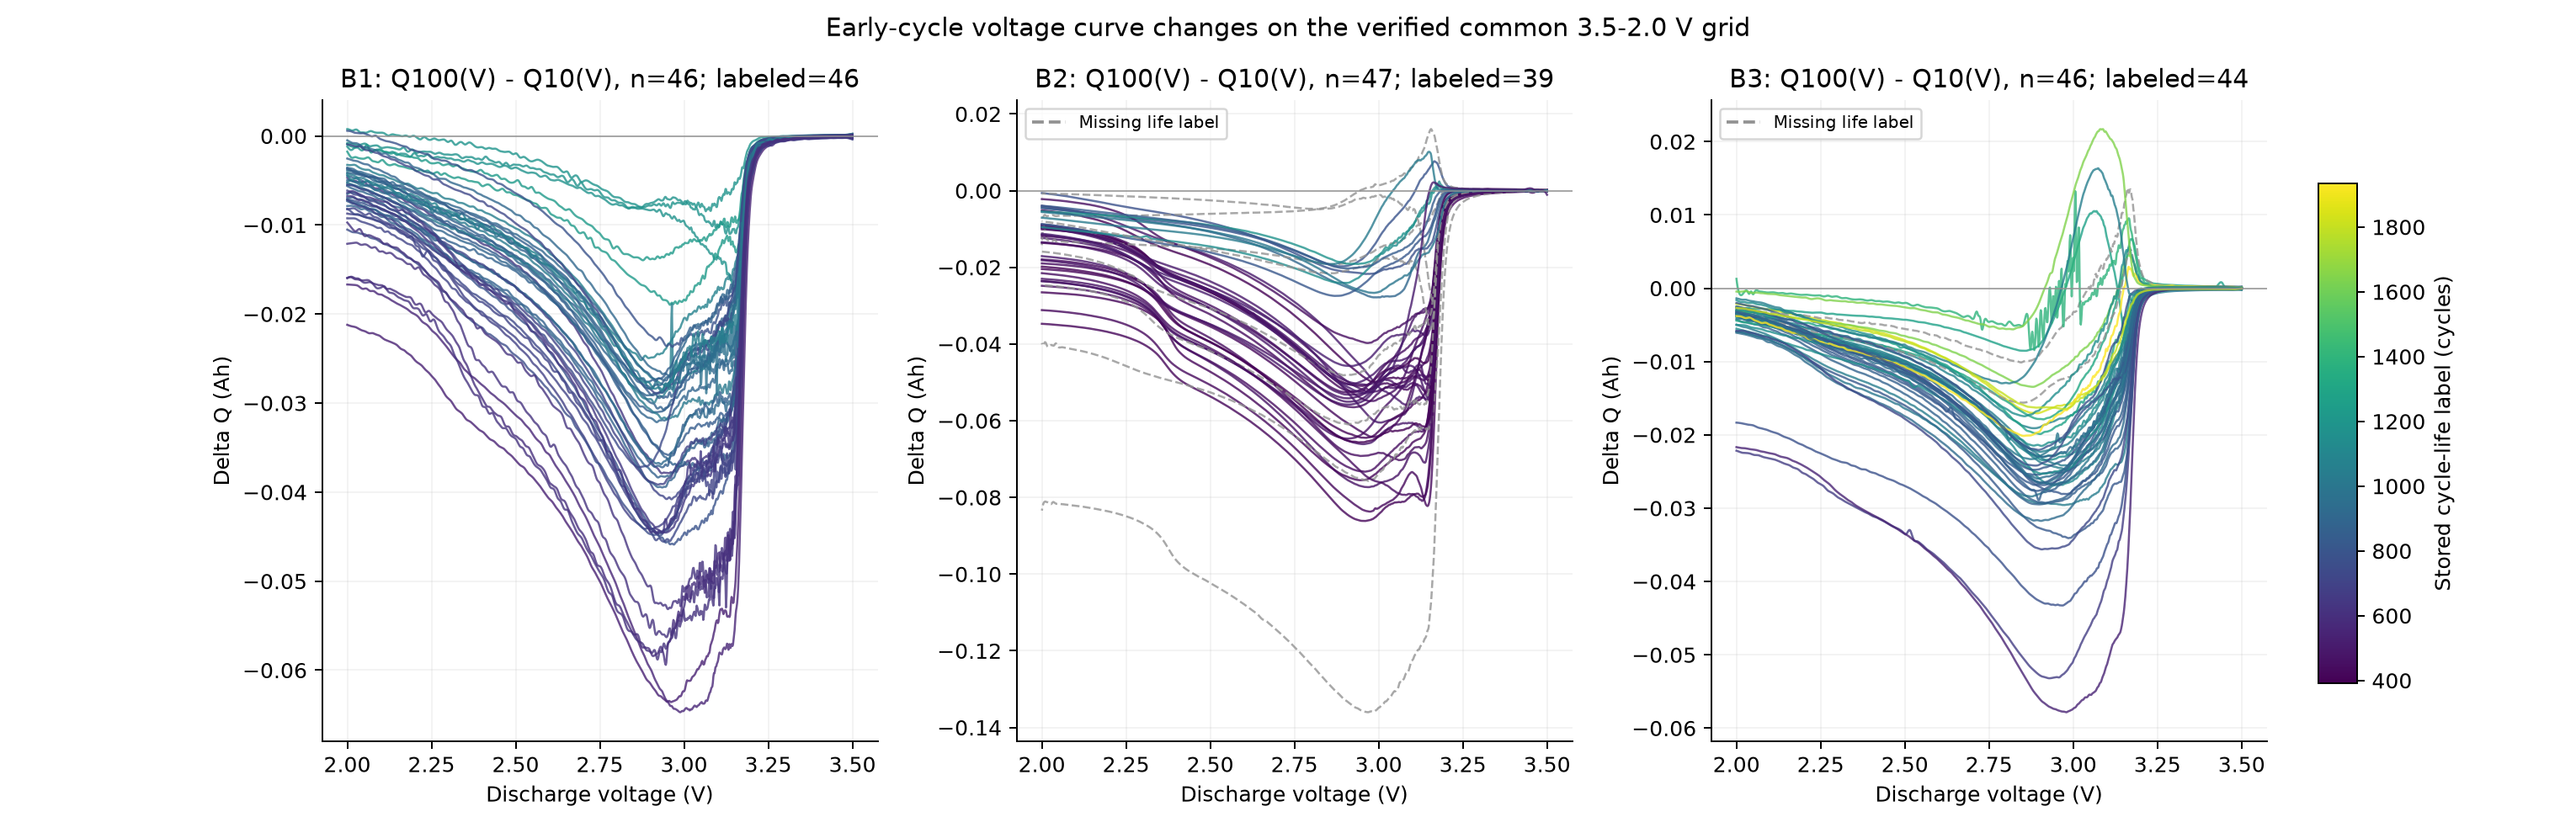

In [7]:
display(Image(filename=str(OUT / 'delta/delta_q_curves.png')))


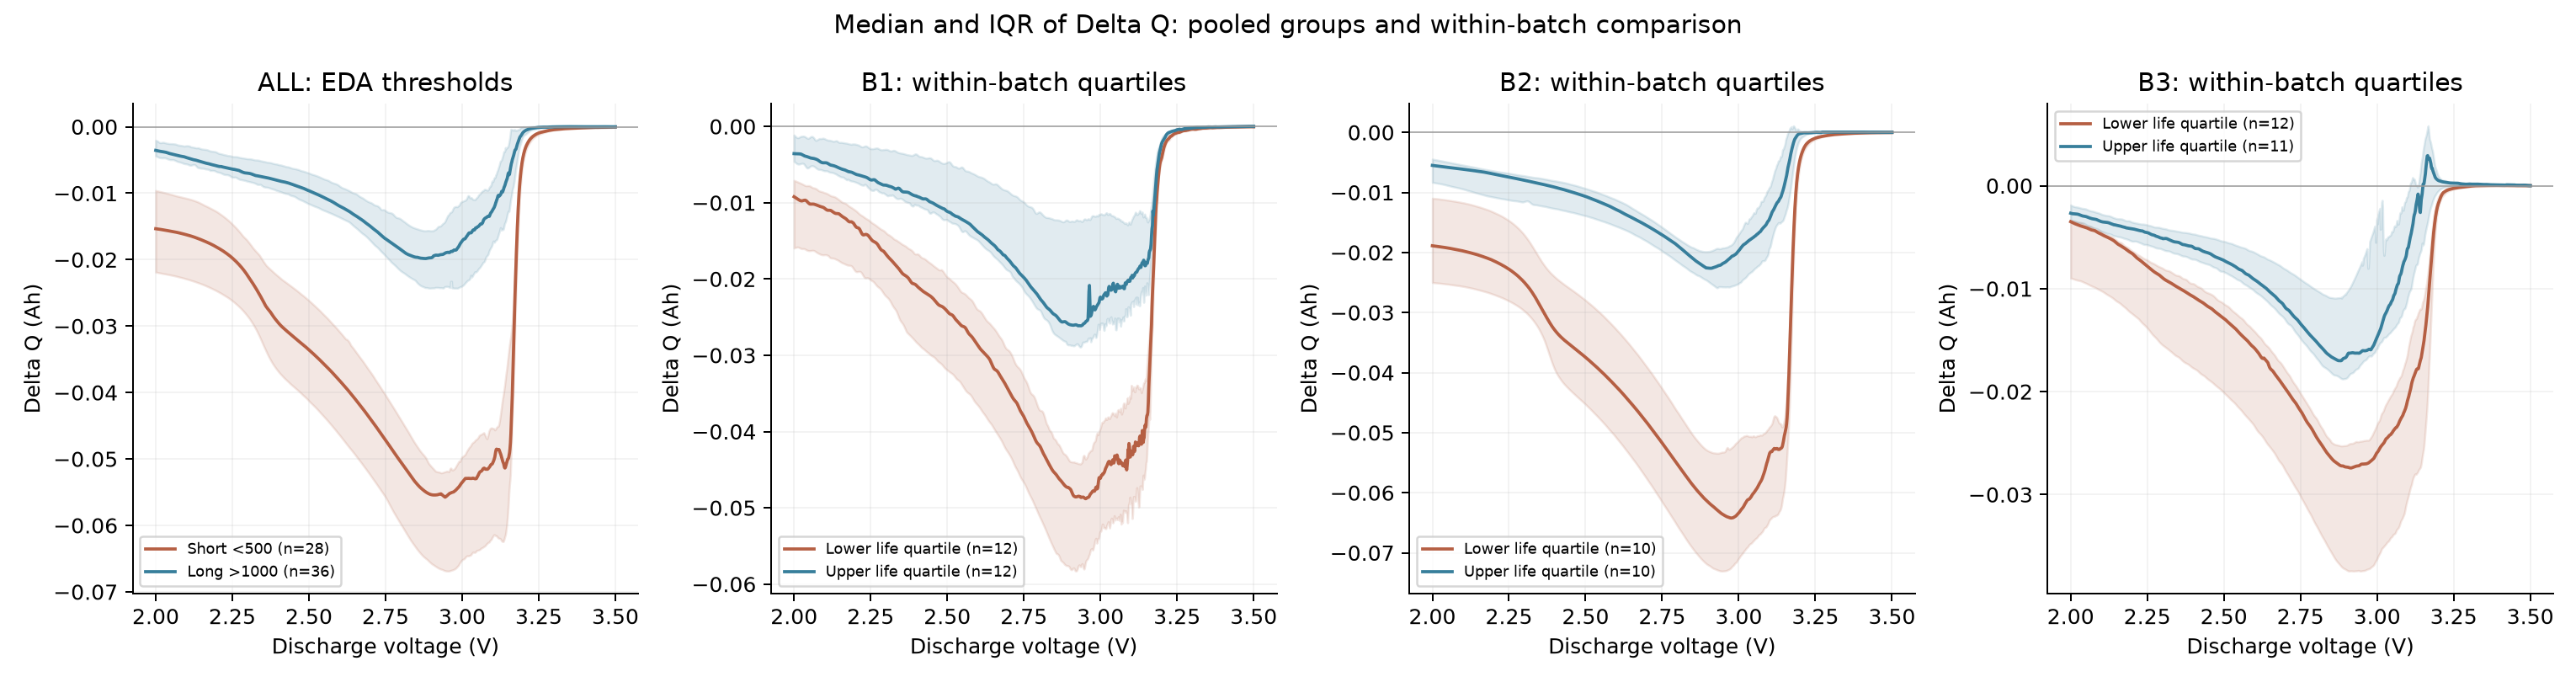

In [8]:
display(Image(filename=str(OUT / 'delta/delta_life_group_shapes.png')))


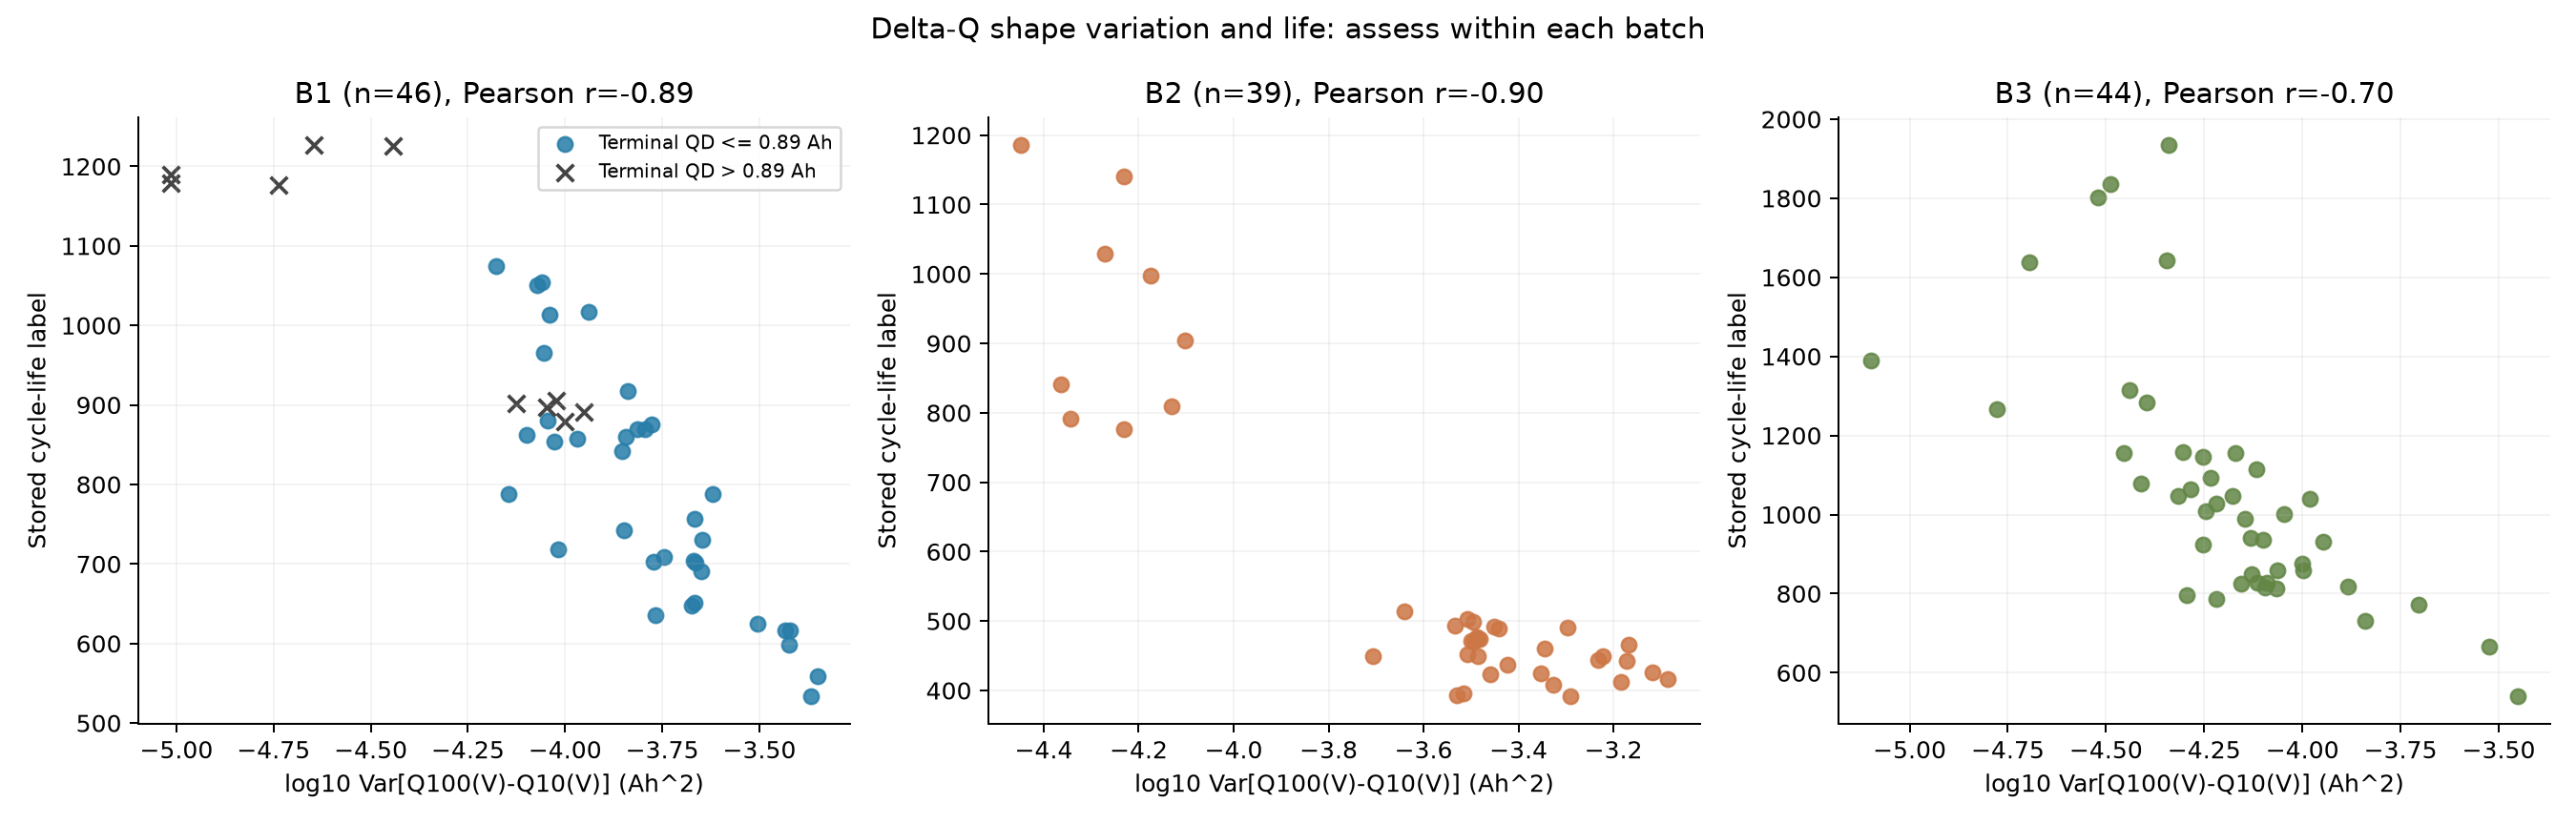

In [9]:
display(Image(filename=str(OUT / 'delta/delta_feature_vs_life.png')))


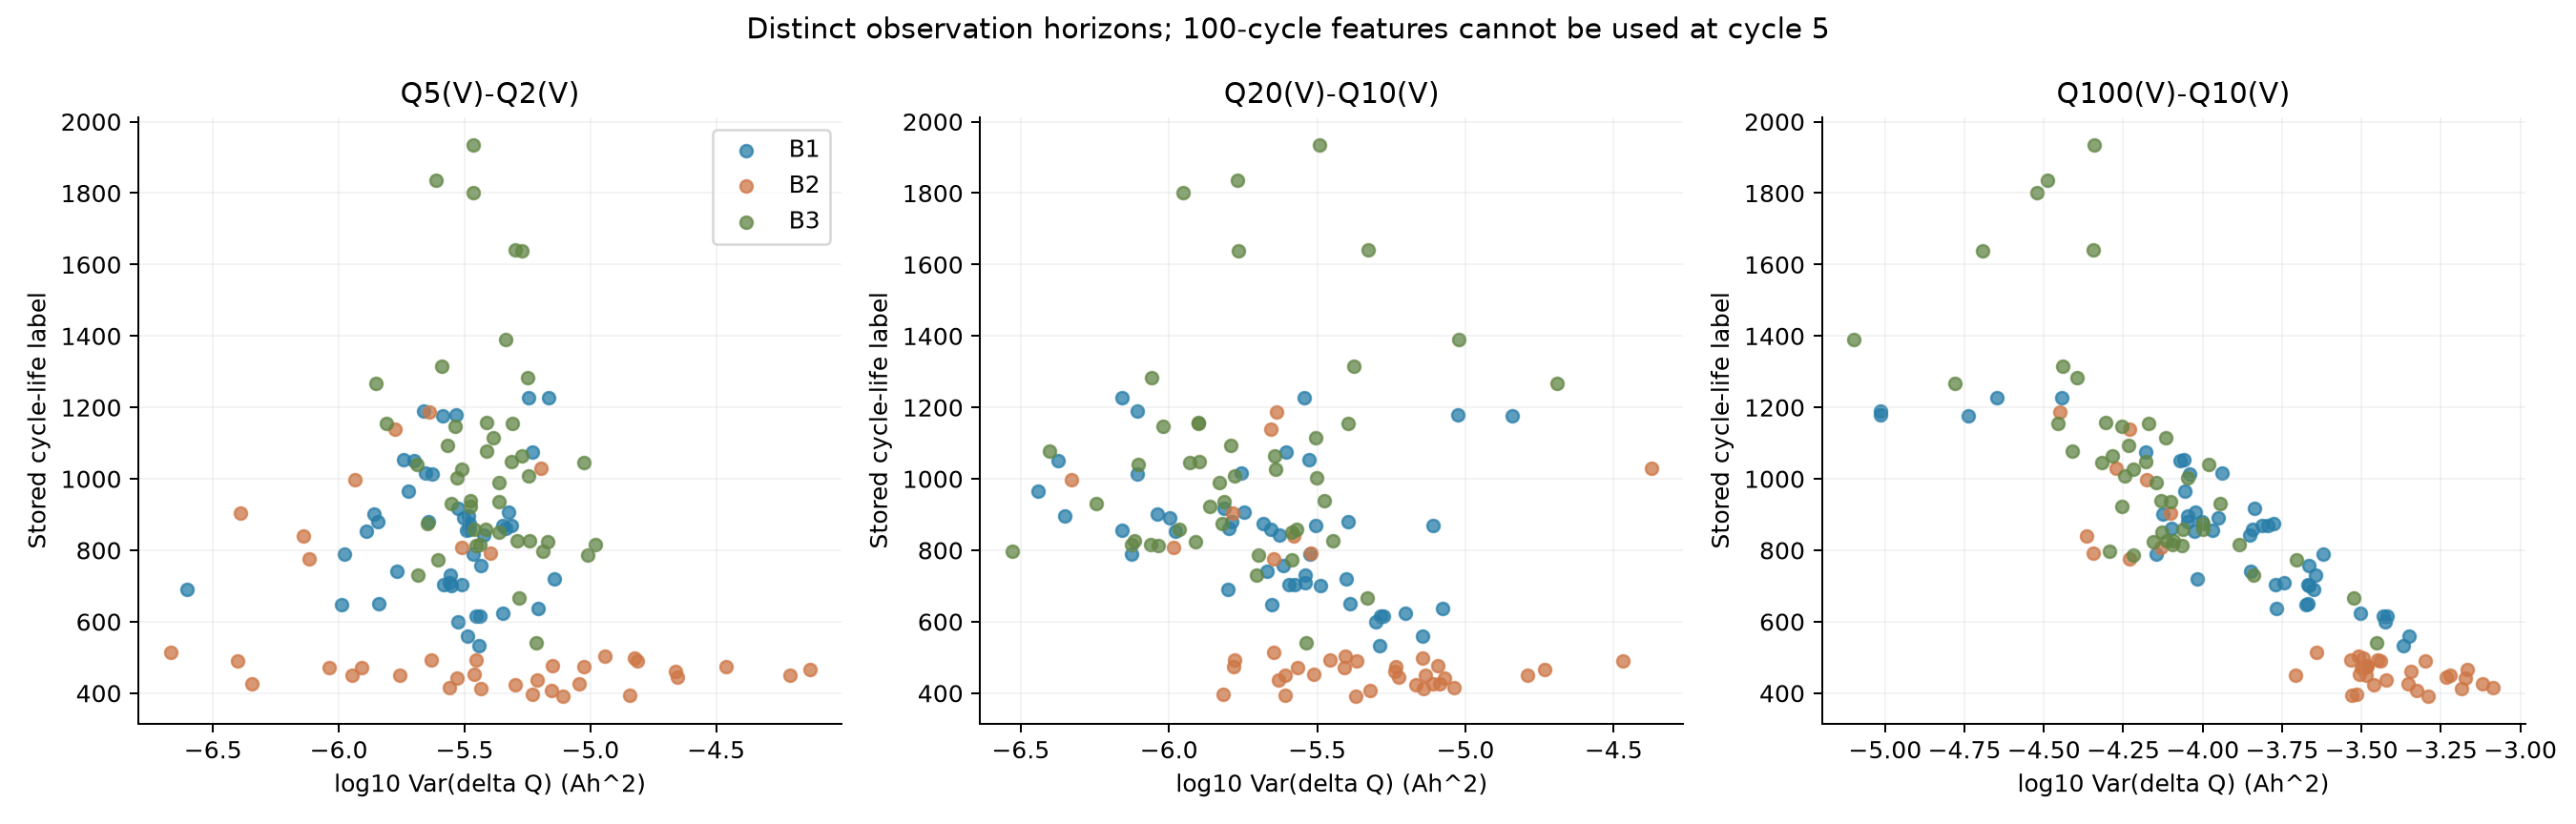

In [10]:
display(Image(filename=str(OUT / 'delta/delta_observation_windows.png')))


## 4 충전 프로토콜과 수명 및 열화 속도

정책별 평균·표준편차와 유효 라벨 n을 함께 비교했다. B1의 `4C(80%)-4C`는 평균 1226.5(n=2), `3.6C(80%)-3.6C`는 1182(n=3), `5.4C(80%)-5.4C`는 546.5(n=2)다. 높은 C-rate와 짧은 수명의 연관은 일부 비교에서 보이지만 최고 전류값 하나의 단조 관계는 아니다. B1 상위 정책에는 EOL까지 완전히 관측되지 않은 라벨도 포함된다.

표준 `C1(Q1)-C2`는 0→Q1%에서 C1, Q1→80%에서 C2다. 80→100%에는 공통 1C CC-CV를 적용한다. 전류와 전환 SOC를 분리한 이유는 같은 최고 C-rate라도 적용 구간이 다르기 때문이다. `c_eff_0_80`은 이상적인 80%까지의 CC 시간을 표현하는 파생 변수다. 실제 충전시간과 같지는 않다. [원 논문 Methods](https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf)

파싱상 같은 `4.8C(80%)-4.8C`의 수명 평균은 B1 **753(n=2)**, B2 **629.1(n=8)**, B3 **1564.2(n=6)**다. 같은 정책 문자열만으로 배치의 시험 조건이 같다고 할 수 없다. `-newstructure`는 스케줄 이름에서 유래한 표기이며 물리적 셀 구조 변경이 확인됐다는 의미가 아니다. [저자 데이터 생성 코드](https://github.com/chueh-ermon/BMS-autoanalysis/blob/c82ab7704211a6aee75bd926714b82d1f95e1a0e/cell_analysis.m)

B2의 같은 4.8C 파싱 정책도 원본 이름을 나누면 일반 표기 **483.6(n=5)**, `-newstructure` 표기 **871.7(n=3)**다. 접미사를 먼저 합치면 이 집단 차이가 숨겨지므로 원본 정책 통계와 파싱 정책 통계를 모두 남겼다. 스케줄 집단의 수명 차이를 물리적 구조 변경 효과로 해석하지 않았다.

C1–후기20% QD slope의 Spearman은 고용량 제외 집합에서 전체 **−0.083(n=130)**, B1 **−0.554(n=45)**, B2 **−0.197(n=39)**, B3 **−0.537(n=46)**다. 음의 slope는 용량 감소를 뜻하므로 B1·B3에서는 높은 C1과 빠른 후기 감소의 연관이 보인다. 전체 관계가 약하다는 이유로 영향이 없다고 판단할 수 없고, 배치별 관계로 인과효과를 확정할 수도 없다.

B2/B3의 파싱된 정책은 이상적인 0→80% 유효 C-rate가 약 4.8C에 집중한다. 이 제한된 범위에서 충전속도 자체와 수명을 구별하기 어렵다. 초기·후기 slope 상관은 [정책과 속도 표](../results/eda/knee/policy_degradation_correlations.csv)에 n과 함께 저장했다.

정책 설명에 더해 **실제 cycle 10의 I/t 파형**을 분석했다. 저장 I 단위는 A가 아니라 C-rate이고 t는 분이다. 첫 I<−0.5C 방전 전, 인접 양끝 I>0.1C·dt>0인 구간만 active 충전으로 정의해 시간 가중 평균·RMS·전류 분산·충전시간·5C 초과 시간비율을 추출했다. 139/139셀이 유효하며 **초기100 평균이 아닌 cycle10 한 회의 특징**이다. rest를 제외한 양의 CC/CV 구간이 포함되므로 동일 SOC 단계만의 비교도 아니다.

| 배치 | 유효 파형 n | 평균 C 중앙값 | RMS C 중앙값 | active 시간 중앙값(분) |
| --- | --- | --- | --- | --- |
| B1 | 46 | 2.339 | 3.121 | 25.005 |
| B2 | 47 | 2.390 | 3.141 | 24.670 |
| B3 | 46 | 2.429 | 3.164 | 24.097 |

실측 RMS–수명은 전체 Pearson **−0.432**, Spearman **−0.323(n=129)**이며 배치별 Spearman은 **−0.856/−0.382/−0.241(n=46/39/44)**이다. B1에서 특히 강하고 다른 배치에서는 약하다. B2 최단/최장 셀의 active 평균은 2.399/2.510C인데 수명은 392/1186이다. B3도 2.476/2.485C로 비슷하지만 541/1935다. 평균 하나로 수명 순위를 설명할 수 없어 실제 단계·적용 시간과 정책 조건을 함께 볼 필요가 있다.

RMS–초기2–100 QD slope의 전체 Pearson은 **−0.672(n=139)**지만 고용량 경험 9셀을 제외하면 **−0.206(n=130)**으로 약해진다. 후기20% slope는 전체 **−0.263(n=139)**, 고용량 제외 **−0.421(n=130)**이다. 고용량·관측 종료 민감도를 고려하며 강한 전류–초기 열화 관계나 인과효과로 단정하지 않는다. 후기 slope는 설명용 사후 결과다.

[프로토콜별 평균과 반복 수](../results/eda/summary/06_policy_life_with_n.png), [정책별 통계](../results/eda/summary/policy_stats.csv), [정책과 초기·후기 열화](../results/eda/knee/policy_vs_early_and_late_degradation.png), [실측 충전 전류 파형](../results/eda/current/cycle10_charge_current_representatives.png), [실측 특징·정의·한계](../results/eda/current/findings.md)

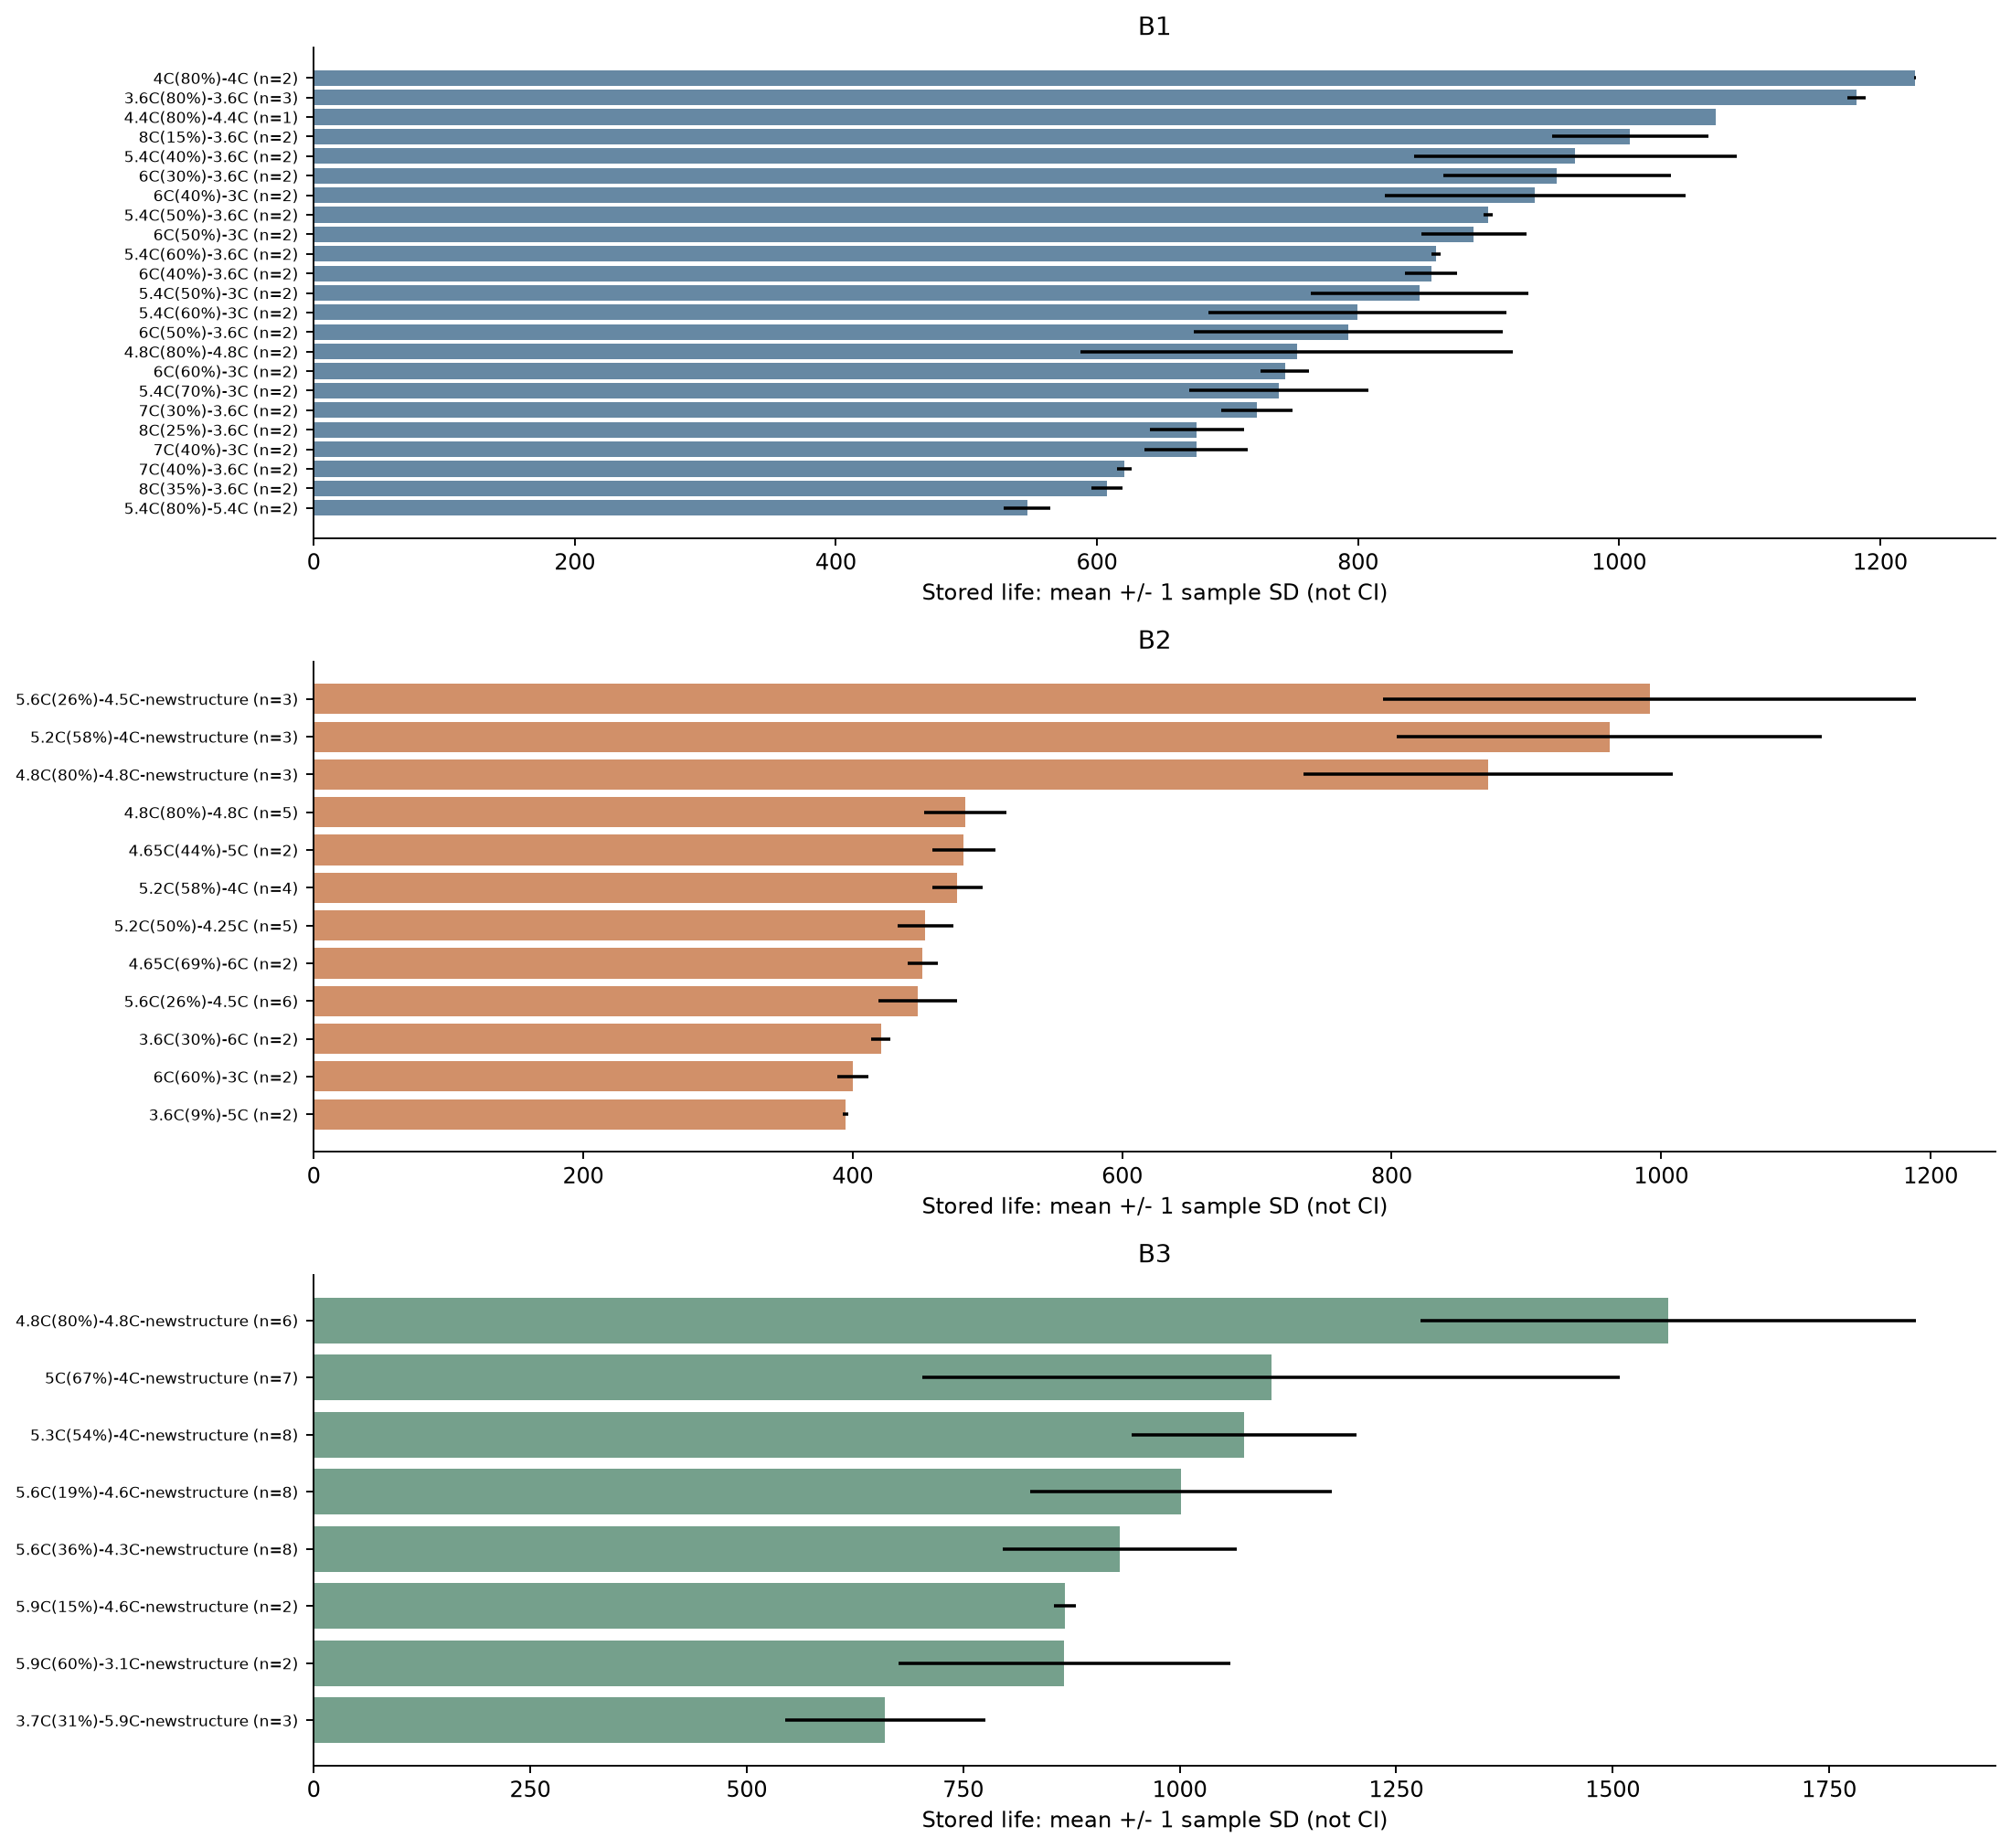

In [11]:
display(Image(filename=str(OUT / 'summary/06_policy_life_with_n.png')))


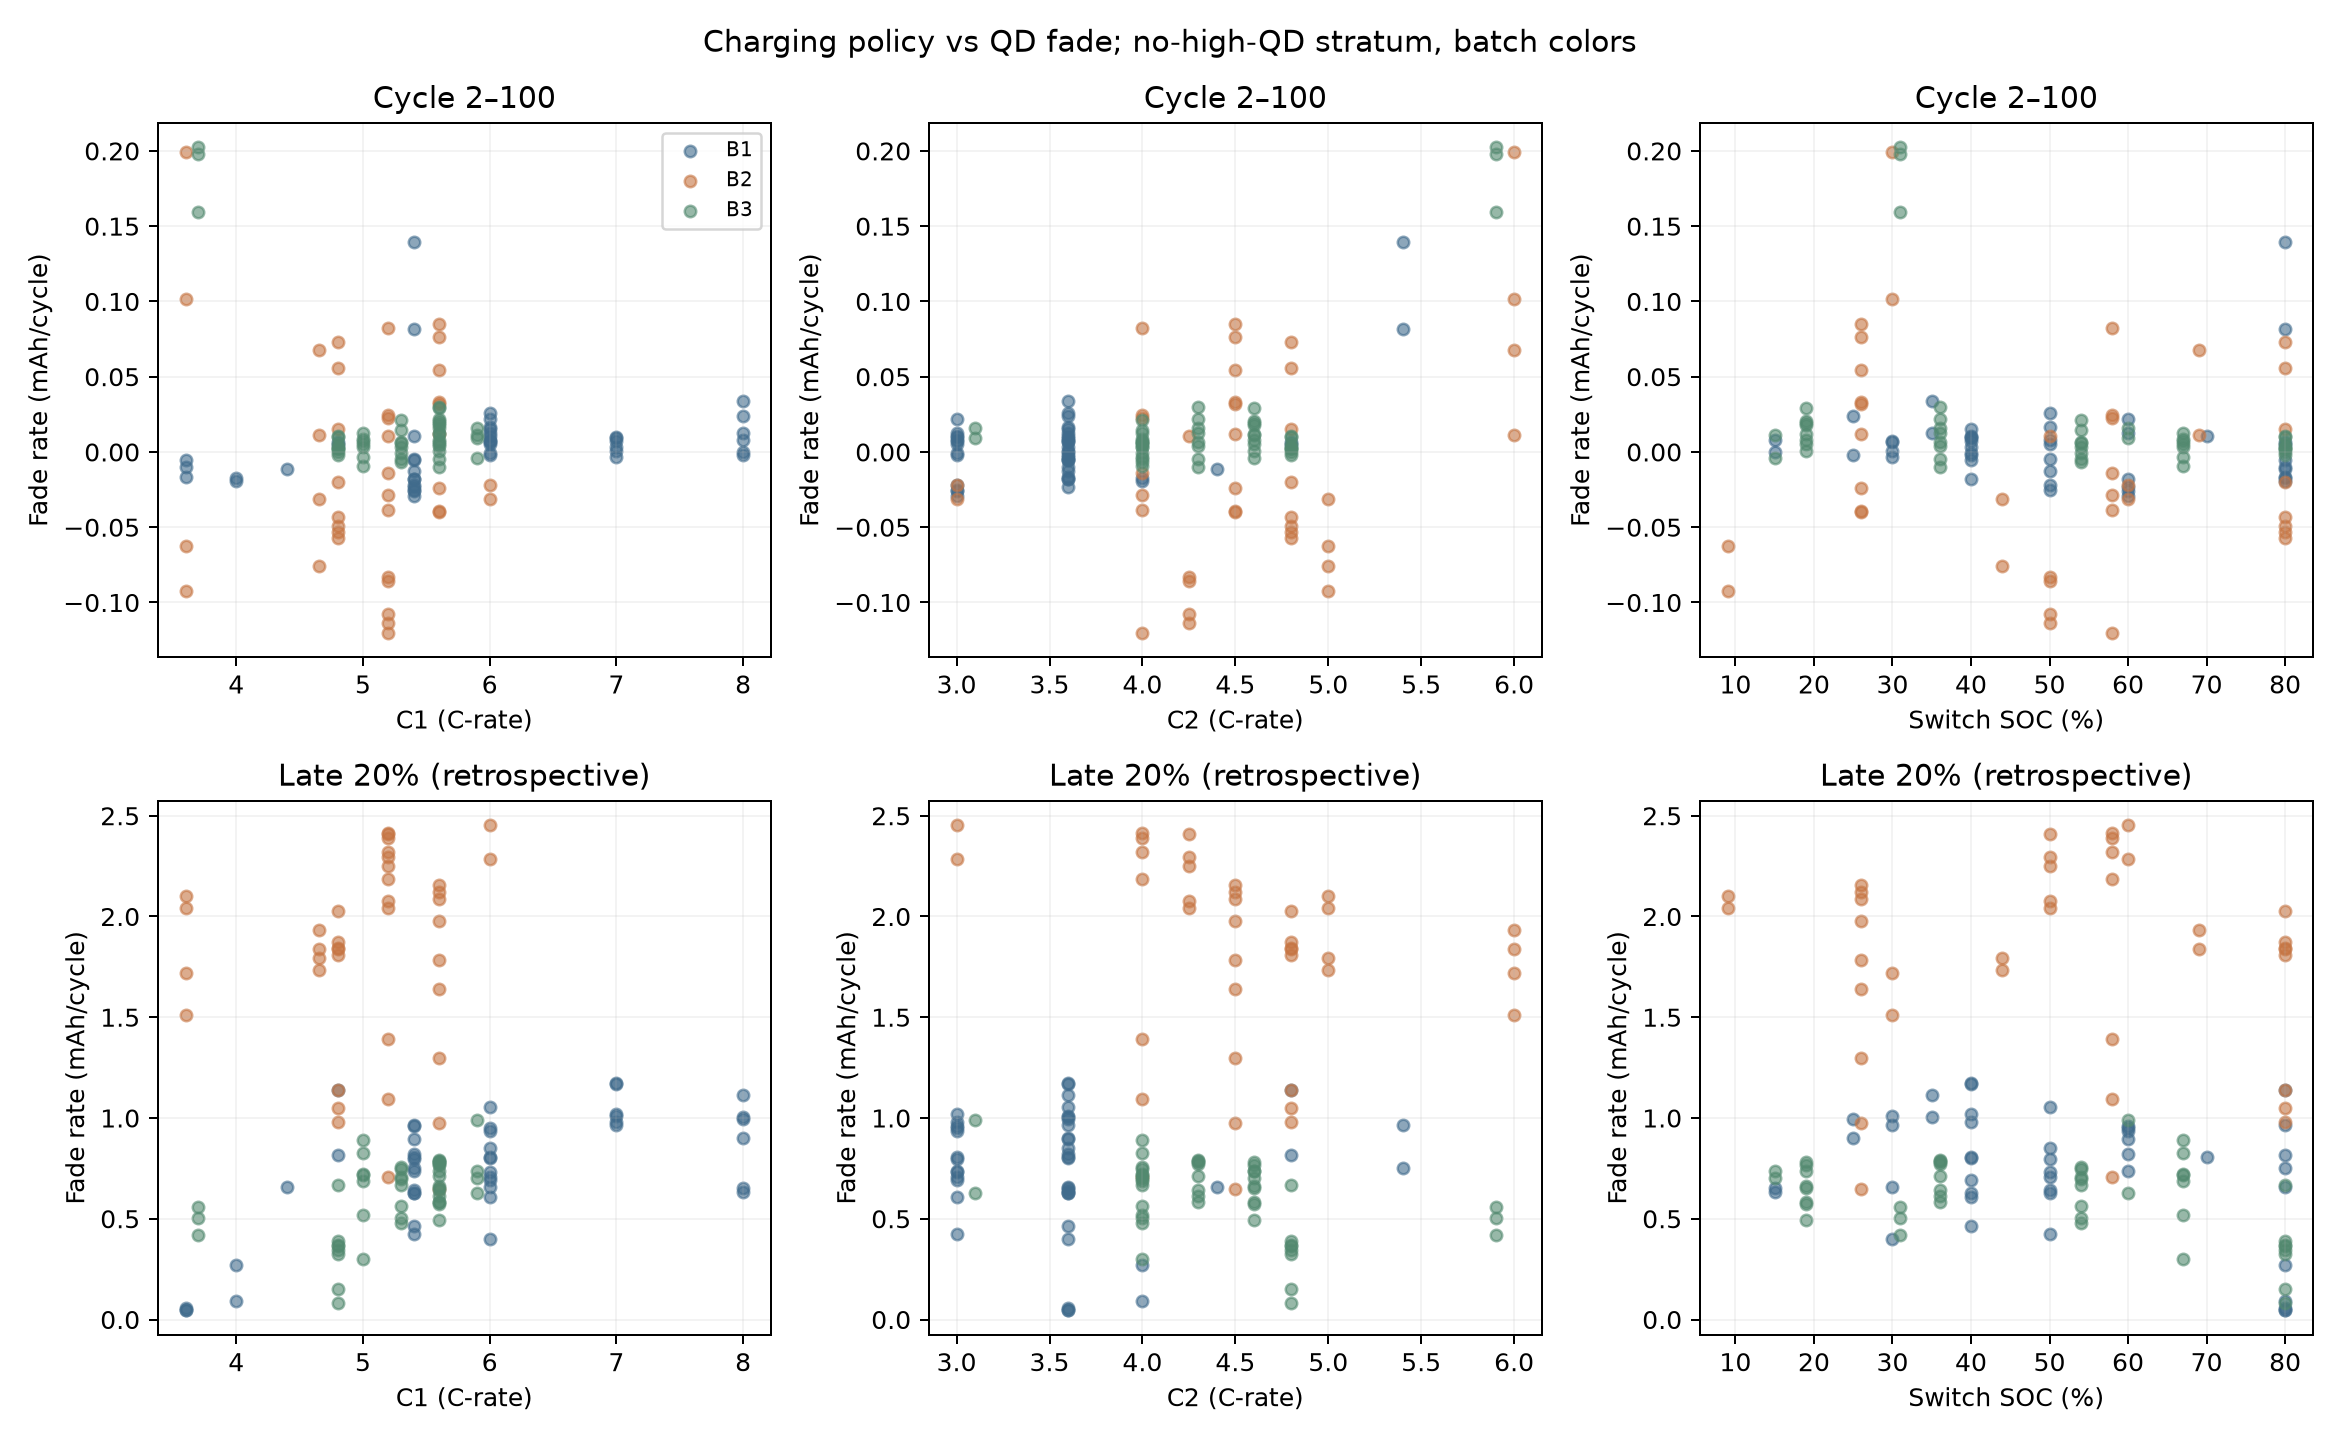

In [12]:
display(Image(filename=str(OUT / 'knee/policy_vs_early_and_late_degradation.png')))


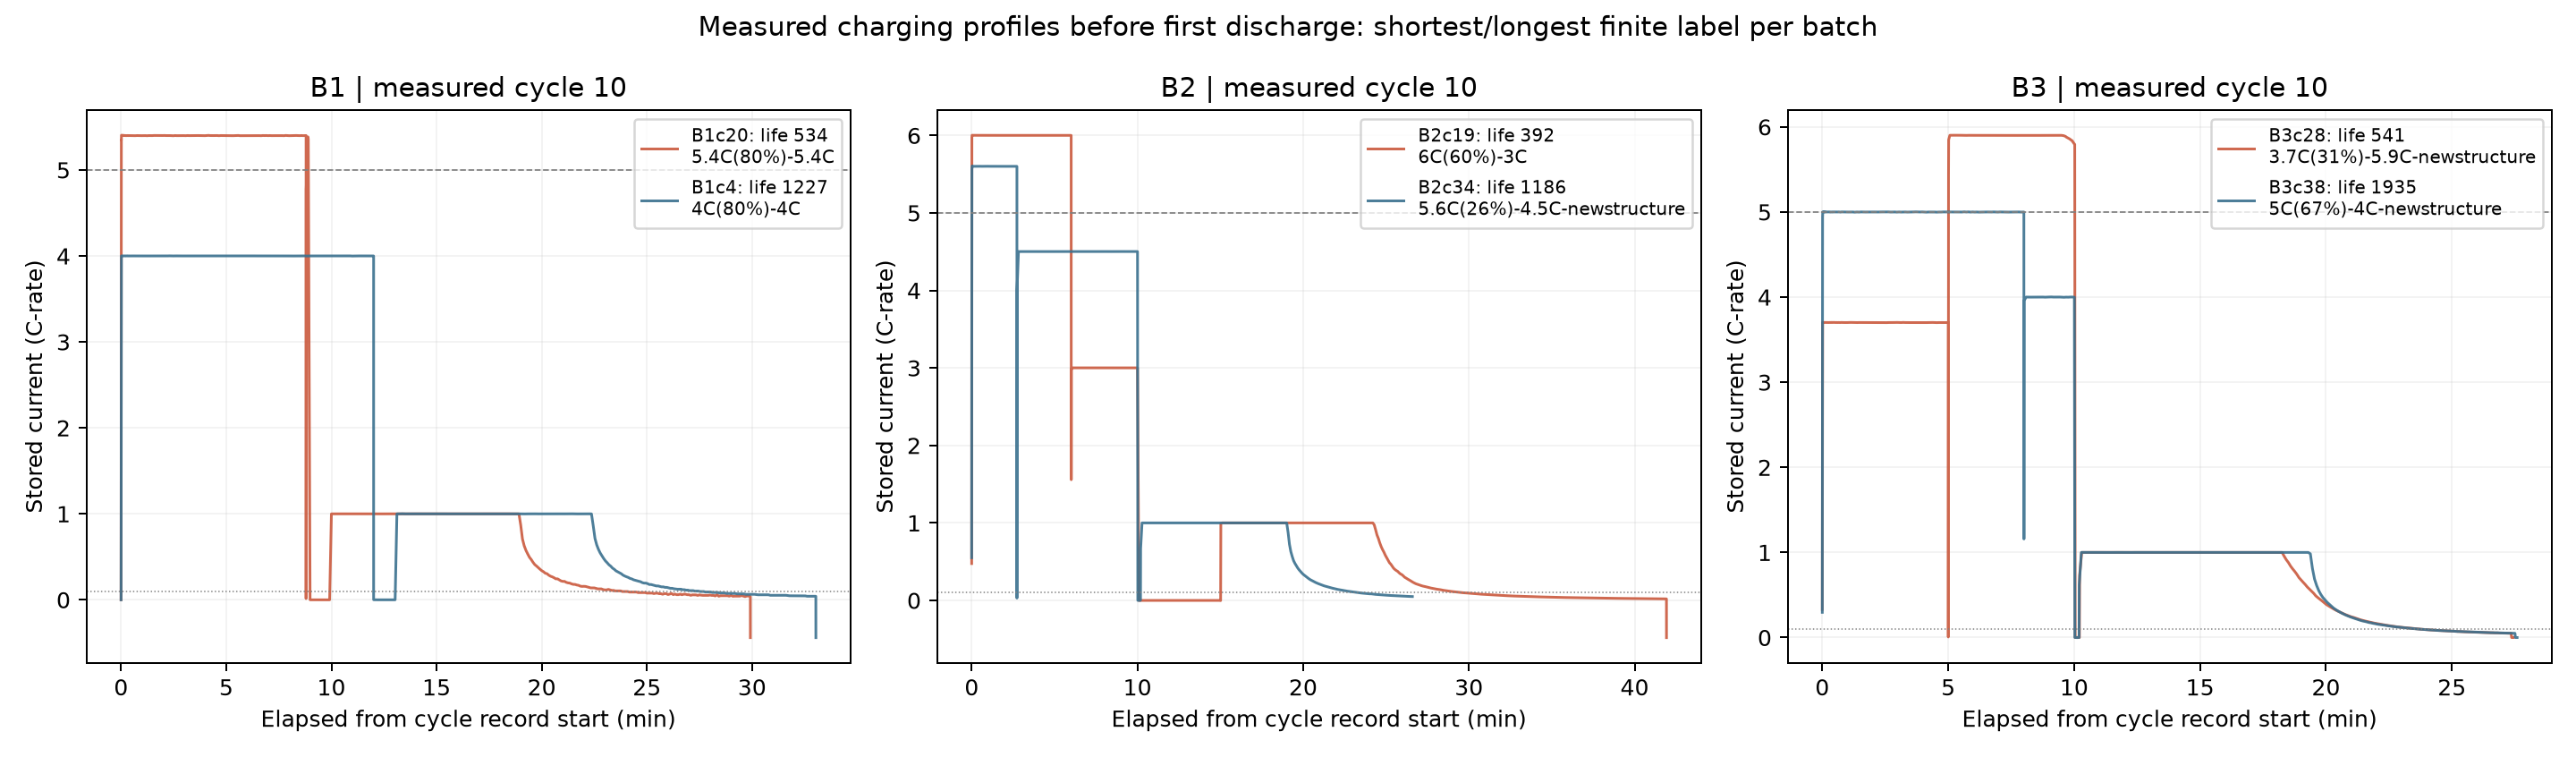

In [13]:
display(Image(filename=str(OUT / 'current/cycle10_charge_current_representatives.png')))


## 5 초기 특징의 상관과 다중공선성

초기 summary 특징은 실제 사이클 2–100에서 계산했다. IR zero를 결측으로 분리해 수명과 함께 유효한 IR 표본은 **123개**, 대부분의 다른 특징은 129개다. 다음은 Pearson r이며 p값에 의한 확정 유의성 주장이 아니라 탐색적 관계다.

| feature | 전체 | B1 | B2 | B3 | 배치 내 중심화 | n 전체 |
| --- | --- | --- | --- | --- | --- | --- |
| dq100_10_log_variance | -0.851 | -0.886 | -0.902 | -0.702 | -0.773 | 129 |
| dq100_10_abs_min_log | -0.853 | -0.873 | -0.885 | -0.699 | -0.779 | 129 |
| qd2 | -0.525 | 0.086 | -0.284 | 0.155 | -0.013 | 129 |
| qd_early_mean | -0.500 | 0.193 | -0.333 | 0.218 | 0.018 | 129 |
| qd_delta_100_2 | 0.011 | 0.540 | -0.199 | 0.277 | 0.131 | 129 |
| ir_early_mean | -0.336 | 0.218 | -0.626 | 0.190 | -0.037 | 123 |
| tavg_early_mean | 0.239 | -0.482 | 0.425 | -0.022 | 0.002 | 129 |
| tmax_early_mean | -0.017 | -0.404 | 0.019 | -0.106 | -0.140 | 129 |
| chargetime_early_mean | -0.194 | 0.577 | 0.087 | 0.637 | 0.075 | 129 |
| chargetime_early_median | 0.315 | 0.744 | -0.918 | 0.638 | 0.442 | 129 |
| chargetime_early_mean_qc | 0.311 | 0.739 | -0.917 | 0.637 | 0.439 | 129 |
| c_max | -0.260 | -0.580 | -0.161 | -0.657 | -0.395 | 129 |
| cycle10_rms_c_timeweighted | -0.432 | -0.891 | -0.207 | -0.507 | -0.461 | 129 |
| cycle10_variance_c2_timeweighted | -0.505 | -0.907 | -0.307 | -0.675 | -0.595 | 129 |
| cycle10_time_fraction_above_5c | -0.267 | -0.500 | -0.100 | -0.464 | -0.353 | 129 |

**배치 평균 차이와 극단값에 따른 착시가 크다.** 평균 QD는 전체 r=−0.500이지만 배치 내 중심화하면 +0.018이다. 충전시간 원본 평균은 B1 +0.577, B3 +0.637인데 전체 −0.194다. 평균 온도는 B1 −0.482, B2 +0.425, B3 −0.022다. 따라서 기존 노트북의 “느린 충전은 항상 장수명”, “발열이 짧은 수명을 유발했다”라는 문장을 세 배치에 일반화할 수 없다. 배치 중심화는 조건 통제나 인과 분석을 대신하지 않는다.

충전시간을 중앙값으로 표현하면 전체 Pearson은 **+0.315**, 배치 중심화는 **+0.442**이며, 60분 초과를 제외한 민감도 평균도 +0.311로 바뀐다. 긴 시간이 측정 오류라고 확정한 것은 아니다. 중앙값의 배치별 r은 B1 +0.744, B2 −0.918, B3 +0.638이다. B2의 높은 음의 관계도 스케줄 접미사 집단으로 나누면 −0.255와 +0.084로 약해진다. 전체 중앙값의 Spearman은 −0.028이므로 일관된 단조 관계라고 해석하지 않는다. **raw 평균을 보존하면서 중앙값을 대체 후보로 비교**하는 이유다. [충전시간 민감도](../results/eda/summary/10_charge_time_sensitivity.png)

다중공선성도 실제로 확인했다. 유한 라벨 129개에서 로그 ΔQ 분산과 로그 절대 최솟값 사이 r=**0.968**, QD2와 QD100 r=**0.950**이다. Tavg–Tmax는 전체 **0.880**, 배치별 **0.956·0.825·0.971**이다. 이들 특징이 서로 비슷한 정보를 제공하는 이유로 설명할 수 있다.

`QD100 = QD2 + (QD100−QD2)`이므로 세 특징을 같이 넣으면 정확한 선형 종속으로 VIF가 무한대다. 중복 후보 집합에서는 로그 ΔQ 분산 VIF=19.66, 로그 최소값 VIF=16.60이다. 분산 하나, QC QD2·변화량, Tavg 하나, 충전시간 중앙값·C1·C2·전환 SOC의 **비교용 후보 집합**은 VIF 1.55–2.41이다. 원본 충전시간 평균을 쓰는 비교 집합은 1.12–2.08이다. VIF가 더 작다는 이유만으로 극단값에 민감한 원본 평균이 더 좋은 입력이라고 할 수 없다. 이는 예측 성능을 검증한 결과가 아니라 중복을 진단한 것이다.

IR 기울기와 raw QD 표준편차의 r=−0.902는 QC QD 표준편차를 사용하면 **−0.0004**로 바뀐다. B1c18의 고용량 한 점을 제외하면 그 셀의 QD 표준편차가 0.18252→0.001705Ah로 감소한다. 공유 극단값으로 생긴 상관을 독립적인 물리 신호의 중복으로 잘못 해석하면 안 된다. [Summary의 QC 비교](../results/eda/summary/findings.md)

실측 cycle10 특징에서도 평균 전류–active 시간 r=**−0.950**, RMS–active 시간 r=**−0.911**, 평균–RMS r=**0.897**이다. 정의상 RMS²=평균²+분산이며 이 비선형 관계와 강한 선형 근사가 중복을 키운다. 전류의 평균·RMS·분산·시간·5C 초과 비율을 모두 넣은 비교 집합은 RMS VIF **1498**, 평균 VIF **813**, 분산 VIF **333**으로 매우 크다. 동일한 초기 보조 특징에 **RMS와 5C 초과 비율**을 넣는 별도 비교 집합은 VIF **1.22–2.70**이다. 후자를 확정 채택한 것은 아니며 분산 등과 대체 비교할 후보로 보관했다.

중심화한 Spearman은 부분 Spearman이 아니다. 중심화 Pearson의 저장 p값도 배치 평균 추정 자유도를 조정하지 않은 탐색 값이다. 변수 순위의 표본 내 상관만으로 최종 모델이나 일반화 성능을 확정하지 않았다.

[특징 중복 그래프](../results/eda/integrated/feature_redundancy.png), [특징 간 상관과 유효 n](../results/eda/integrated/feature_pair_correlations.csv), [VIF 비교](../results/eda/integrated/vif_diagnostics.csv), [변수 분포와 통계](../results/eda/integrated/feature_distributions.csv)

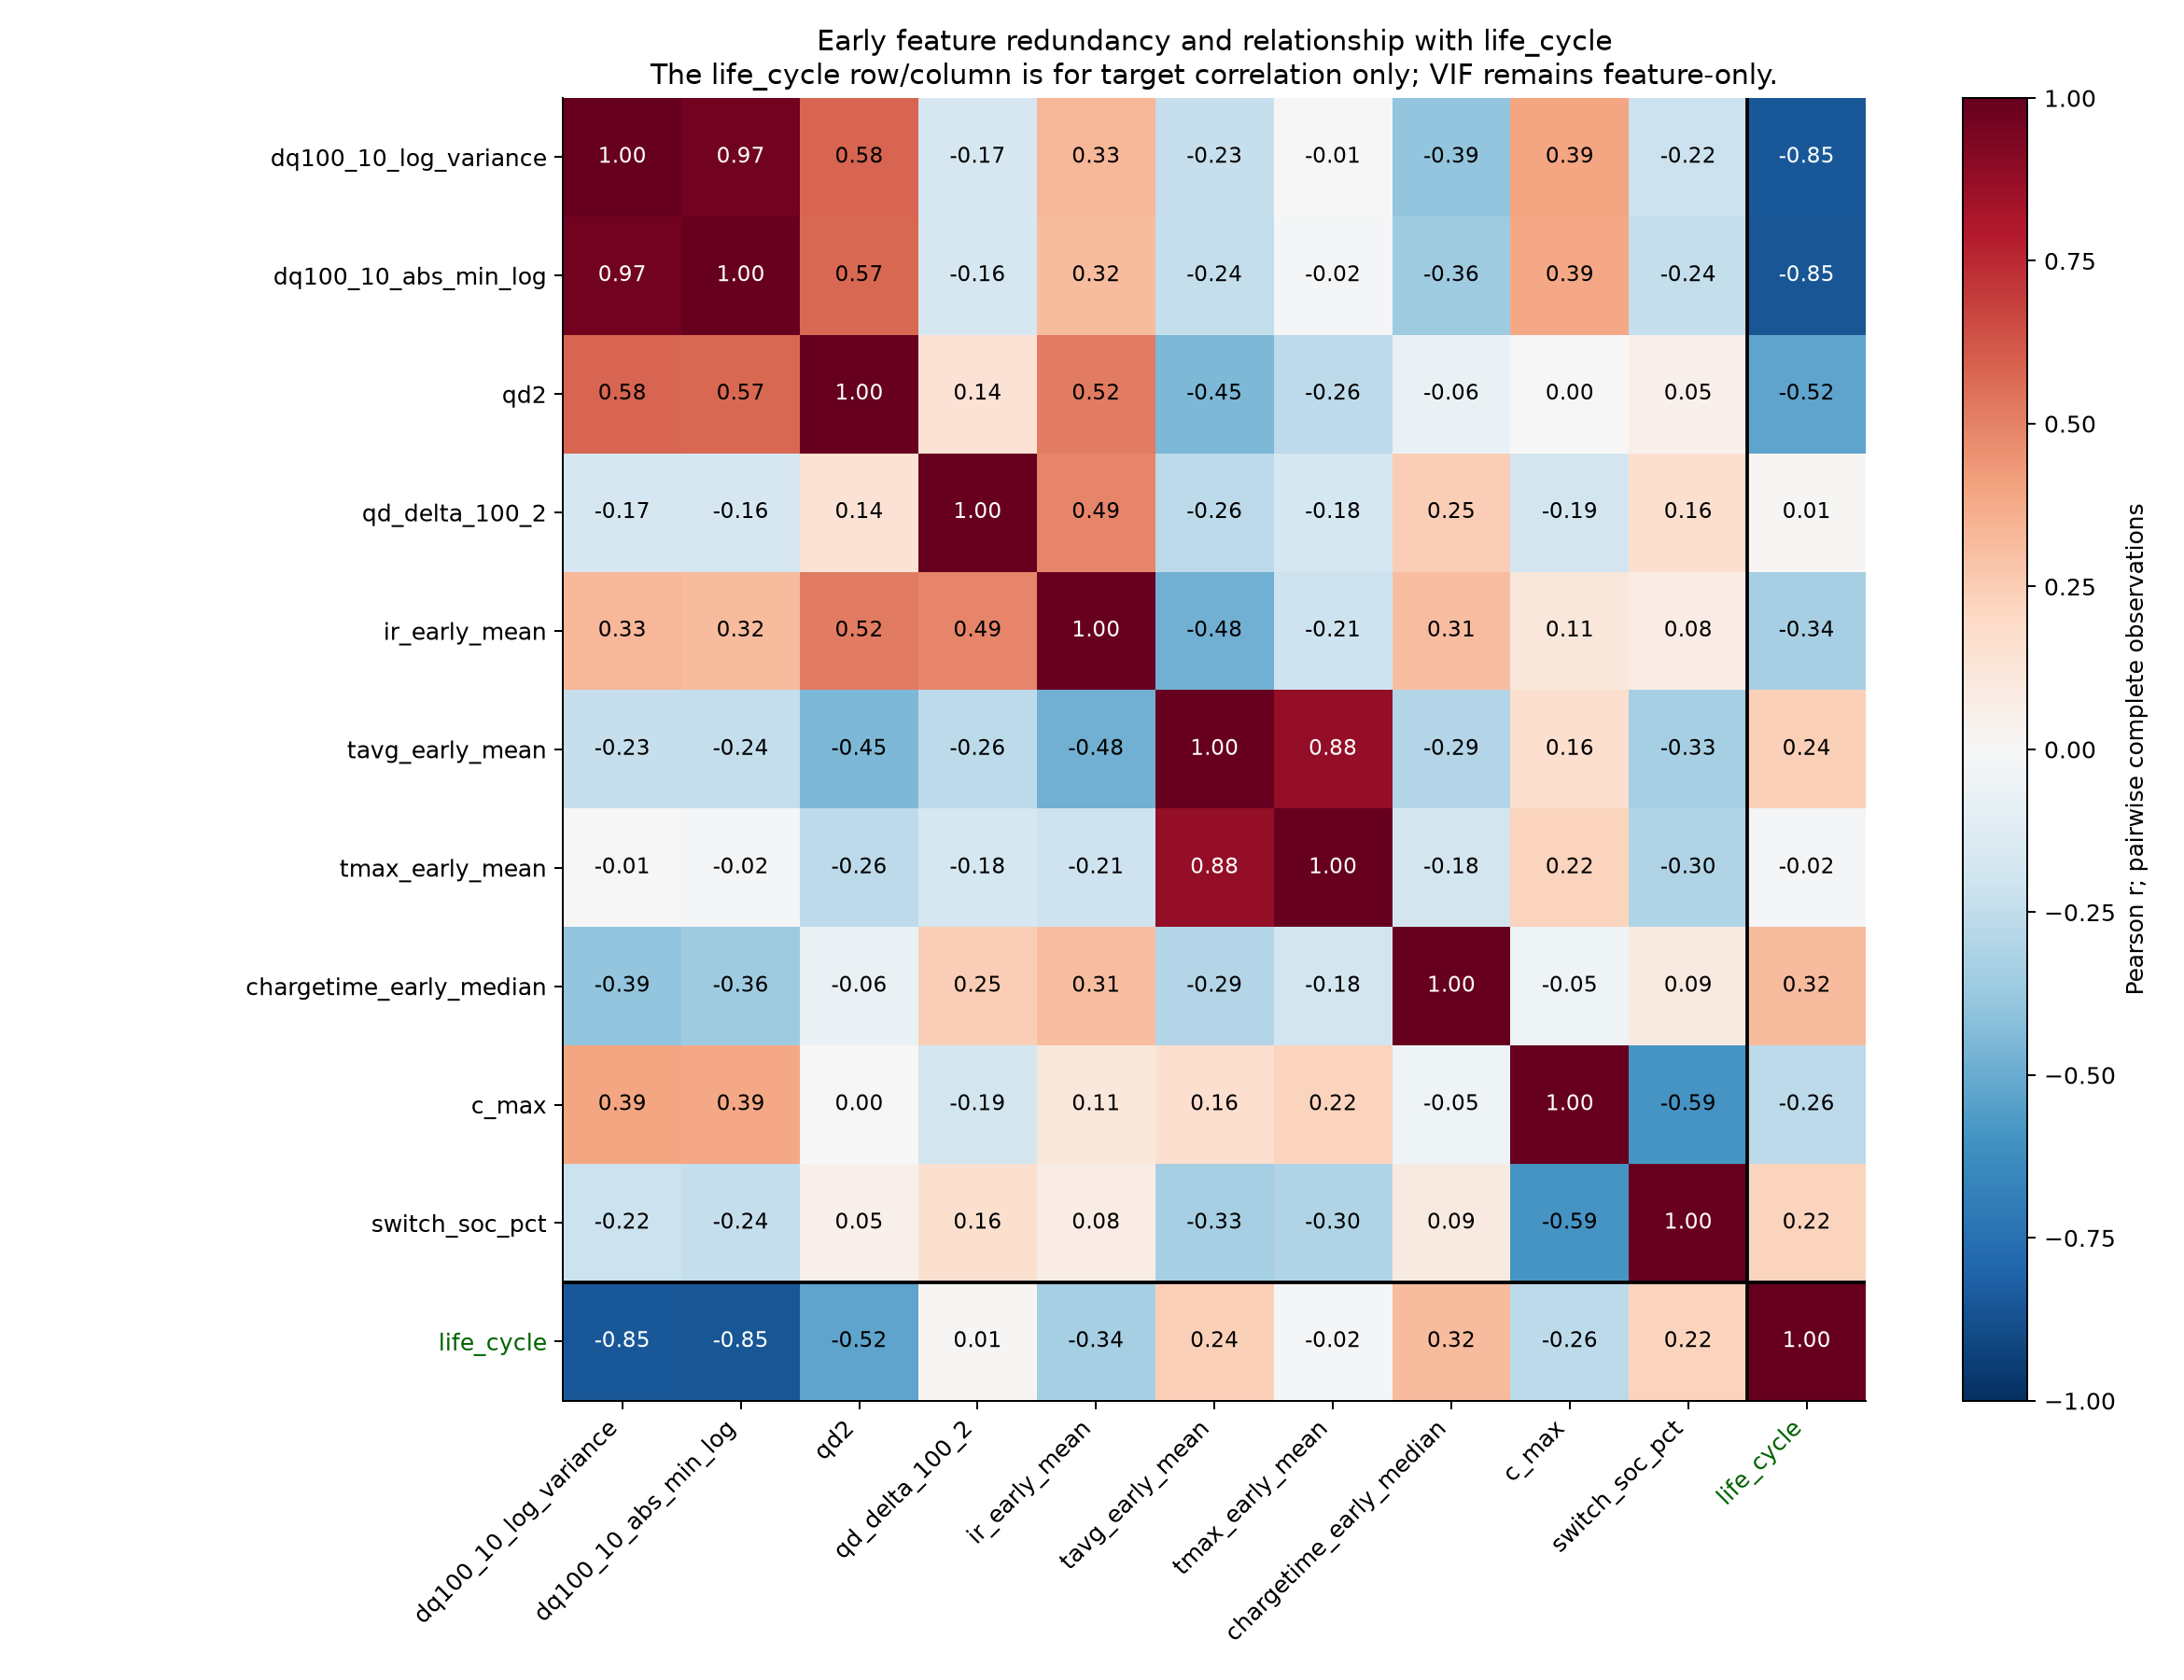

In [17]:
display(Image(filename=str(OUT / 'integrated/feature_redundancy.png')))


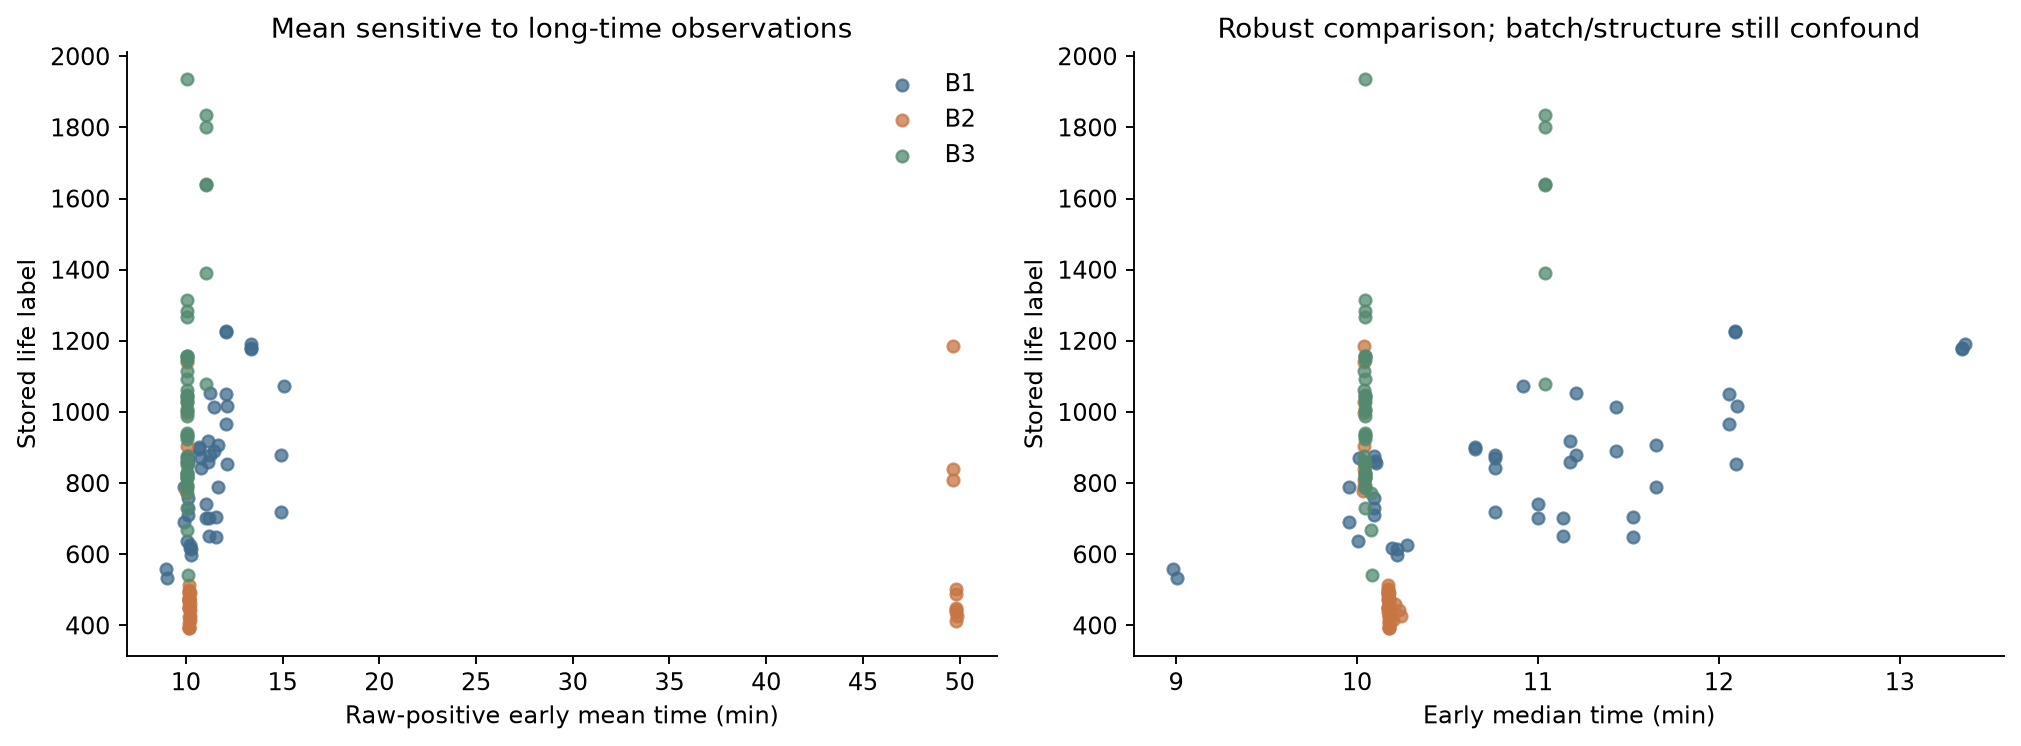

In [15]:
display(Image(filename=str(OUT / 'summary/10_charge_time_sensitivity.png')))


## 잠정 특징 후보와 선택 이유

| 후보 또는 처리 | 선택 이유 | 장점과 한계 |
| --- | --- | --- |
| `log10 Var(ΔQ100−10)` 우선 비교 | 모든 배치에서 강한 음의 수명 관계가 유지됨 | 곡선 변화 요약이 간결함. 100사이클 필요, 보간·진단 조건 및 수명 라벨 QC에 영향받음 |
| `log10 abs(min ΔQ)` 대체 비교 | 전체 관계가 약간 더 크지만 분산과 r=0.968 | 두 값을 동시에 넣으면 중복과 계수 불안정 가능. 대체 후보로 검증 |
| `QD2`와 `QD100−QD2` | 초기 수준과 변화량을 분리 | 세 배치에서 단독 관계가 안정적이지 않아 보조·비교 후보. `QD100`까지 함께 넣지 않음 |
| Tavg 또는 Tmax | 온도 상태를 요약 | 높은 상호 상관으로 우선 하나씩 비교. 배치별 수명 관계의 부호가 달라 원인 지표로 단정하지 않음 |
| C1·C2·전환 SOC 또는 유효 C-rate | 최고 전류 하나보다 적용 구간을 설명 | 파생값과 원본 정책을 무조건 모두 넣지 않음. 가변·진단 정책에 일반식 적용 금지 |
| 초기 충전시간 중앙값 또는 QC 평균 | 긴 시간의 극단값 민감도를 줄여 초기 충전 동작을 요약 | 원본 평균과 비교하고 배치·스케줄별 검증 필요. 긴 시간을 오류로 단정하지 않음 |
| cycle10 실측 RMS 또는 전류 분산, 5C 초과 active 시간비율 | 실제 파형의 전류 크기·불균일성·단계 적용 시간을 요약 | 평균·RMS·분산·시간을 동시에 넣지 않고 대체 비교. cycle10 한 회이며 5C 근처 측정 흔들림과 배치 조건에 민감 |
| IR 수준·변화와 결측 플래그 | 초기 저항 상태와 측정 가능성을 분리 | 유효 n=123. zero를 실제 저항으로 채우지 않음. 결측 패턴이 시험 프로토콜을 나타낼 가능성 |
| Knee·후기 slope·끝 QD·관측 길이 | 열화 설명과 수명 라벨 QC | 초기 예측 시점 뒤 정보이므로 예측 입력에서 제외 |

위 목록은 EDA 근거로 **향후 검증할 후보**이며 확정 채택이나 모델 학습 결과가 아니다. 최종 테스트 배치의 탐색 결과를 본 뒤 변수까지 고르면 순수한 최종 평가로 볼 수 없으므로, 모델링 단계에서는 학습 배치 안에서 선택·전처리를 확정하고 별도 배치로 평가해야 한다.

기존 노트북의 QD 색상은 여전히 셀 번호 순서지만 새 ΔQ 색상은 실제 수명이다. 두 그림의 색상 해석을 구분한다. EOL 계산 오류, 필터의 해석, 수염으로 예측 난도를 추정한 문장 등의 수정 권고는 [최신 노트북 해석 검토](../results/eda/notebook_interpretation_audit.md)에 기록했다. [도메인 근거 검토](../results/eda/domain_review.md)와 [분석·변수 선정 근거 기록](../results/eda/decision_log.md)도 함께 보관한다.

## 재검증과 상세 통계

아래 표에는 특징별 유효 n과 사분위·분산, VIF 비교가 포함됩니다. 코드 전체를 다시 실행하면 최신 CSV와 그림을 읽습니다.

In [16]:
distribution = pd.read_csv(OUT / 'integrated/feature_distributions.csv')
selected = ['dq100_10_log_variance', 'qd2', 'qd_delta_100_2', 'ir_early_mean', 'tavg_early_mean', 'chargetime_early_median', 'cycle10_rms_c_timeweighted', 'cycle10_time_fraction_above_5c']
print(distribution.loc[distribution.feature.isin(selected), ['batch', 'feature', 'n_valid', 'n_missing', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(5).to_string(index=False))
print('\nVIF 비교\n', pd.read_csv(OUT / 'integrated/vif_diagnostics.csv').round(3).to_string(index=False))
print('DAY1 EDA 결과입니다. DAY2 학습·평가 결과는 03_modeling.ipynb와 성능 보고서에 기록합니다.')


batch                        feature  n_valid  n_missing     mean     std      min      25%      50%      75%      max
  ALL          dq100_10_log_variance      139          0 -3.92291 0.45302 -5.09842 -4.22513 -4.00025 -3.51213 -2.68448
  ALL                            qd2      139          0  1.07787 0.01422  1.04627  1.06805  1.07584  1.09011  1.10928
  ALL                 qd_delta_100_2      139          0  0.03150 0.18025 -0.06879  0.00050  0.00202  0.00375  1.08397
  ALL                  ir_early_mean      132          7  0.01624 0.00120  0.01342  0.01539  0.01627  0.01672  0.02177
  ALL                tavg_early_mean      139          0 33.35038 1.41706 29.88151 32.44324 33.14772 33.94901 38.56624
  ALL        chargetime_early_median      139          0 10.55146 1.45281  6.78008 10.04313 10.17314 10.84124 24.21724
  ALL     cycle10_rms_c_timeweighted      139          0  3.17082 0.32992  1.81943  3.10018  3.14177  3.22818  5.55996
  ALL cycle10_time_fraction_above_5c      139   